In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import sklearn.metrics as skm
from scipy.stats import ks_2samp
import math
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import spearmanr

# silence warnings
import warnings
warnings.filterwarnings('ignore')

# binning
try:
    from optbinning import OptimalBinning
except:
    ! pip install optbinning
    from optbinning import OptimalBinning

# catboost
try:
    import catboost as cb
except:
    ! pip install catboost
    import catboost as cb

(CVXPY) Dec 18 12:07:33 AM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Dec 18 12:07:33 AM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')


#### Functions

In [2]:
def target_by_data_set(df, str_target):
    df_tmp = df.groupby(by='data_set', as_index=False).agg({
        str_target: 'mean',
    })
    df_tmp['sort'] = df_tmp['data_set'].map(dict_sort)
    df_tmp.sort_values(by='sort', ascending=True, inplace=True)
    df_tmp.drop('sort', axis=1, inplace=True)

    # plot
    x = df_tmp['data_set']
    y = df_tmp[str_target]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by Data Set')
    ax.set_xlabel('Data Set')
    ax.set_ylabel(f'Mean {str_target}')
    # bars
    bars = ax.bar(x, y)
    # add labels to the bars
    ax.bar_label(bars, fmt='%.4f')
    # show
    plt.show()

In [3]:
def target_by_feature(df, str_col, str_target):
    df_tmp = df[df['data_set'] == 'train'].groupby(by=str_col, as_index=False).agg({
        str_target: 'mean',
    })

    # plot
    x = df_tmp[str_col].astype(str)
    y = df_tmp[str_target]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by {str_col}')
    ax.set_xlabel('Data Set')
    ax.set_ylabel(f'Mean {str_target}')
    # bars
    bars = ax.bar(x, y)
    # add labels to the bars
    ax.bar_label(bars, fmt='%.4f')
    # show
    plt.show()

In [4]:
def target_by_feature_quantile(df, str_col, int_n_quantiles, str_target):
    # get quantile
    df_tmp = df[df['data_set'] == 'train'].copy()
    # replace infs with nan
    df_tmp[str_col] = df_tmp[str_col].replace(np.inf, np.nan)
    # drop missing rows
    df_tmp = df_tmp.dropna(subset=[str_col])
    # get quantile
    df_tmp['quantile'] = pd.qcut(df_tmp[str_col], q=int_n_quantiles, duplicates='drop')
    # min-max
    df_tmp['min'] = df_tmp[str_col]
    df_tmp['max'] = df_tmp[str_col]
    # get target mean by quangtile
    df_tmp = df_tmp.groupby(by='quantile', as_index=False).agg({
        'min': 'min',
        'max': 'max',
        str_target: 'mean',
    })
    # sort
    df_tmp.sort_values(by='min', ascending=True, inplace=True)
    # rank
    df_tmp['quantile'] = range(1, df_tmp.shape[0]+1)
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'{str_target} by {str_col} Quantile')
    ax.set_xlabel(f'{str_col} Quantile')
    ax.set_ylabel(str_target)
    ax.plot(df_tmp['quantile'].astype(str), df_tmp[str_target])
    plt.show()

In [5]:
def get_suggested_constraints(df, list_cols_model, str_target, int_n_quantiles):
    list_dict_row = []
    for col in tqdm(list_cols_model):
        # df_tmp
        df_tmp = df.copy()
        # replace infs with nan
        df_tmp[col] = df_tmp[col].replace(np.inf, np.nan)
        # drop missing rows
        df_tmp = df_tmp.dropna(subset=[col])
        # get number of unique values
        int_n_unique = df_tmp[col].nunique()
        # logic
        if int_n_unique <= int_n_quantiles:
            # create a feature named quantile
            df_tmp['quantile'] = df_tmp[str_col]
        else:
            # get quantile
            df_tmp['quantile'] = pd.qcut(df_tmp[col], q=int_n_quantiles, duplicates='drop')
        # min-max
        df_tmp['min'] = df_tmp[col]
        df_tmp['max'] = df_tmp[col]
        # get target mean by quangtile
        df_tmp = df_tmp.groupby(by='quantile', as_index=False).agg({
            'min': 'min',
            'max': 'max',
            str_target: 'mean',
        })
        # sort
        df_tmp.sort_values(by='min', ascending=True, inplace=True)
        # create rank column
        df_tmp['rank'] = range(1, df_tmp.shape[0]+1)
        # fit trend line
        try:
            flt_slope, flt_intercept = np.polyfit(x=df_tmp['rank'], y=df_tmp[str_target], deg=1)
        except:
            flt_slope = 0
            flt_intercept = 0
        # logic for monotone contraints
        if flt_slope > 0:
            int_constraint = 1
            str_imputation = 'max'
        elif flt_slope < 0:
            int_constraint = -1
            str_imputation = 'min'
        else:
            int_constraint = 0
            str_imputation = 'none'
        # make a row
        dict_row = {
            'feature': col,
            'intercept': flt_intercept,
            'slope': flt_slope,
            'constraint': int_constraint,
            'imputation': str_imputation,
        }
        list_dict_row.append(dict_row)
    # make a df
    df = pd.DataFrame(list_dict_row)
    # return
    return df

In [6]:
class OverSampling:
    def __init__(self, df, str_target, flt_target_value, flt_current_value):
        self.df = df
        self.str_target = str_target
        self.flt_target_value = flt_target_value
        self.flt_current_value = flt_current_value
    # oversample zeros
    def oversample_zeros(self):
        # get n zeros
        df_zeros = self.df[self.df[str_target] == 0].copy()
        int_n_zeros_original = df_zeros.shape[0]
        # get n ones
        df_ones = self.df[self.df[str_target] == 1].copy()
        int_n_ones_original = df_ones.shape[0]
        # get total
        int_n_total_original = int_n_zeros_original + int_n_ones_original
        # solve for the new n total to reach target
        int_n_total_new = math.ceil(int_n_ones_original / flt_target_value)
        # get n additional 0s
        int_n_additional_zeros = int_n_total_new - int_n_ones_original - int_n_zeros_original
        # get sample
        df_zeros_additional = df_zeros.sample(n=int_n_additional_zeros, random_state=42)
        # concat
        df = pd.concat([df_zeros, df_ones, df_zeros_additional])
        # shuffle
        df = df.sample(frac=1.0, random_state=42)
        # return
        return df 
    # undersample ones
    def oversample_ones(self):
        # get n zeros
        df_zeros = self.df[self.df[str_target] == 0].copy()
        int_n_zeros_original = df_zeros.shape[0]
        # get n ones
        df_ones = self.df[self.df[str_target] == 1].copy()
        int_n_ones_original = df_ones.shape[0]
        # get total
        int_n_total_original = int_n_zeros_original + int_n_ones_original
        # solve for number of 1s
        int_n_additional_ones = math.ceil((int_n_ones_original - (flt_target_value * int_n_total_original)) / (flt_target_value - 1))
        # get sample
        df_ones_additional = df_ones.sample(n=int_n_additional_ones, random_state=42)
        # concat
        df = pd.concat([df_zeros, df_ones, df_ones_additional])
        # shuffle
        df = df.sample(frac=1.0, random_state=42)
        # return
        return df
    # sample
    def sample(self):
        # logic
        if self.flt_target_value < self.flt_current_value:
            df = self.oversample_zeros()
        else:
            df = self.oversample_ones()
        # return
        return df

In [7]:
def get_catboost_feat_importance(cls_model_inference, pool_eval):
    df_tmp = cls_model_inference.get_feature_importance(
        data=pool_eval,
        type='LossFunctionChange',
        prettified=True,
    )
    df_tmp.columns = ['feature', 'importance']
    df_tmp.sort_values(by='importance', ascending=False, inplace=True)
    return df_tmp

In [8]:
def get_logistic_regression_feat_importance(df, cls_model_inference, list_cols_model=None):
    try:
        list_cols_model = list(cls_model_inference.feature_names_in_)
    except:
        pass
    df_tmp = pd.DataFrame({
        'feature': list_cols_model,
        'importance': list(cls_model_inference.coef_[0]),
    })
    # make into dictionary
    dict_coef = dict(zip(df_tmp['feature'], df_tmp['importance']))
    # subset df
    df_tmp = df[list_cols_model].copy()
    # iterate
    for key, val in dict_coef.items():
        # multiply the feature by the coefficient
        df_tmp[key] = df_tmp[key] * val
    # get the mean for each
    list_dict_row = []
    for col in list_cols_model:
        flt_mean = df_tmp[col].mean()
        dict_row = {
            'feature': col,
            'importance': flt_mean,
        }
        list_dict_row.append(dict_row)
    # make df
    df_tmp = pd.DataFrame(list_dict_row)
    # make abs value
    df_tmp['importance_abs'] = df_tmp['importance'].apply(abs)
    # sort    
    df_tmp.sort_values(by='importance_abs', ascending=False, inplace=True)
    # return
    return df_tmp

In [9]:
# min max scale
def min_max_scale(ser_values):
    # get min
    flt_min = ser_values.min()
    # get max
    flt_max = ser_values.max()
    # range
    flt_range = flt_max - flt_min
    # subtract min
    ser_values = ser_values - flt_min
    # divide by range
    ser_values = ser_values / flt_range
    # return
    return ser_values

In [10]:
def get_scaled_score(df):
    df['flt_eval_metric_valid_scaled'] = min_max_scale(df['flt_eval_metric_valid'])
    df['diff'] = df['flt_eval_metric_train'] - df['flt_eval_metric_valid']
    df['diff_scaled'] = 1 - min_max_scale(df['diff'])
    df['n_feats_scaled'] = 1 - min_max_scale(df['n_feats'])
    list_cols = [
        'flt_eval_metric_valid_scaled',
        'diff_scaled',
        #'n_feats_scaled',
    ]
    df['score'] = df[list_cols].mean(axis=1)
    df.sort_values(by='score', ascending=False, inplace=True)
    return df

In [11]:
# get shap values
def get_shap(cls_model_inference, X, list_cols_model):
    cls_explainer = shap.Explainer(cls_model_inference)
    df_tmp = pd.DataFrame(
        cls_explainer.shap_values(X[list_cols_model]),
        columns=list_cols_model,
    )
    # get avg by col
    ser_mean = df_tmp.mean()
    df_tmp = ser_mean.reset_index()
    df_tmp.columns = ['feature','importance']
    df_tmp['importance'] = df_tmp['importance'].apply(abs)
    # sort
    df_tmp.sort_values(by='importance', ascending=False, inplace=True)
    # return
    return df_tmp

In [12]:
# ks
def get_ks_score(y_true, y_pred):
    # make df
    df_tmp = pd.DataFrame({
        'y_true': y_true,
        'y_pred': y_pred,
    })
    # get mean of y_true
    flt_mean = df_tmp['y_true'].mean()
    # sort
    df_tmp.sort_values(by='y_pred', ascending=False, inplace=True)
    # make row number
    df_tmp['row'] = range(1, df_tmp.shape[0]+1)
    df_tmp['prop_row'] = df_tmp['row'] / df_tmp.shape[0]
    df_tmp['yhat_class'] = df_tmp['y_pred'].apply(
        lambda x: 1 if x <= flt_mean else 0,
    )
    # separate predictions by true class
    ser_pos_scores = df_tmp[df_tmp['y_true'] == 1]['yhat_class']
    ser_neg_scores = df_tmp[df_tmp['y_true'] == 0]['yhat_class']
    # Calculate KS statistic
    ks_stat, p_value = ks_2samp(ser_pos_scores, ser_neg_scores)
    return ks_stat

In [13]:
def evaluate(y_train, list_predictions_train, y_test, list_predictions_test, y_holdout, list_predictions_holdout):
    # get auc
    flt_auc_train = skm.roc_auc_score(
        y_true=y_train,
        y_score=list_predictions_train,
    )
    print(f'AUC Train: {flt_auc_train:0.4f}')
    flt_auc_test = skm.roc_auc_score(
        y_true=y_test,
        y_score=list_predictions_test,
    )
    print(f'AUC Test: {flt_auc_test:0.4f}')
    flt_auc_holdout = skm.roc_auc_score(
        y_true=y_holdout,
        y_score=list_predictions_holdout,
    )
    print(f'AUC Holdout: {flt_auc_holdout:0.4f}')
    print()
    # logloss
    flt_logloss_train = skm.log_loss(
        y_true=y_train,
        y_pred=list_predictions_train,
    )
    print(f'Logloss Train: {flt_logloss_train:0.4f}')
    flt_logloss_test = skm.log_loss(
        y_true=y_test,
        y_pred=list_predictions_test,
    )
    print(f'Logloss Test: {flt_logloss_test:0.4f}')
    flt_logloss_holdout = skm.log_loss(
        y_true=y_holdout,
        y_pred=list_predictions_holdout,
    )
    print(f'Logloss Holdout: {flt_logloss_holdout:0.4f}')
    print()
    # ks
    flt_ks_train = get_ks_score(
        y_true=y_train,
        y_pred=list_predictions_train,
    )
    print(f'KS Train: {flt_ks_train:0.4f}')
    flt_ks_test = get_ks_score(
        y_true=y_test,
        y_pred=list_predictions_test,
    )
    print(f'KS Test: {flt_ks_test:0.4f}')
    flt_ks_holdout = get_ks_score(
        y_true=y_holdout,
        y_pred=list_predictions_holdout,
    )
    print(f'KS Holdout: {flt_ks_holdout:0.4f}')
    return flt_auc_train, flt_auc_test

In [14]:
def get_directions_of_predictions(X, list_predictions, str_target, list_actual, list_cols, int_n_quantiles):
    # assign predictions
    X['yhat'] = list_predictions
    # assign actual
    X[str_target] = list_actual
    # iterate and plot
    for col in tqdm(list_cols):
        # get number of unique values
        int_n_unique = X[col].nunique()
        # logic
        if int_n_unique <= int_n_quantiles:
            # create a feature named quantile
            X['quantile'] = X[col]
        else:
            # get quantile
            X['quantile'] = pd.qcut(X[col], q=int_n_quantiles, duplicates='drop')
        # get target mean by quantile
        X['min'] = X[col]
        # group
        df_tmp = X.groupby(by='quantile', as_index=False).agg({
            'min': 'min',
            'yhat': 'mean',
            str_target: 'mean',
            
        })
        # sort
        df_tmp.sort_values(by='min', ascending=True, inplace=True)
        # rank
        df_tmp['quantile'] = range(1, df_tmp.shape[0]+1)
        # plot
        fig, ax = plt.subplots(figsize=(9,5))
        ax.set_title(f'Mean Predicted and Actual by {col} Quantile')
        ax.set_xlabel(f'{col} Quantile')
        ax.set_ylabel(str_target)
        # predicted
        ax.plot(df_tmp['quantile'].astype(str), df_tmp['yhat'], label='Predicted')
        # actual
        ax.plot(df_tmp['quantile'].astype(str), df_tmp[str_target], label='Actual')
        # legend
        ax.legend()
        # show
        plt.show()

In [15]:
def get_directions_of_predictions_for_scorecard(X, list_predictions, str_target, list_actual, list_cols, df_bins):
    # assign predictions
    X['yhat'] = list_predictions
    # assign actual
    X[str_target] = list_actual
    # iterate and plot
    for col in tqdm(list_cols):
        # map bin label
        df_bins_tmp = df_bins[df_bins['feature'] == col].copy()
        # create dict
        dict_map_bin = dict(zip(df_bins_tmp['bin'], df_bins_tmp['bin_label']))
        # map
        X['bin_label'] = X[col].map(dict_map_bin)
        # group
        df_tmp = X.groupby(by='bin_label', as_index=False).agg({
            'yhat': 'mean',
            str_target: 'mean',
            
        })
        # sort
        df_tmp.sort_values(by='bin_label', ascending=True, inplace=True)
        # plot
        fig, ax = plt.subplots(figsize=(9,5))
        ax.set_title(f'Mean Predicted and Actual by {col} Bin (Ascending)')
        ax.set_xlabel(f'{col} Bin')
        ax.set_ylabel(str_target)
        # predicted
        ax.plot(df_tmp['bin_label'].astype(str), df_tmp['yhat'], label='Predicted')
        # actual
        ax.plot(df_tmp['bin_label'].astype(str), df_tmp[str_target], label='Actual')
        # legend
        ax.legend()
        # show
        plt.show()

In [16]:
def get_mean_actual_by_prediction_quantile(X, list_predictions, list_actual, str_target, int_n_quantiles, str_model_type):
    # assign
    X['yhat'] = list_predictions
    X[str_target] = list_actual
    # get quantile
    X['quantile'] = pd.qcut(X['yhat'], q=int_n_quantiles, duplicates='drop')
    # get min
    X['min'] = X['yhat']
    X['predicted'] = X['yhat']
    # group
    df_tmp = X.groupby(by='quantile', as_index=False).agg({
        'min': 'min',
        'predicted': 'mean',
        str_target: 'mean',
    })
    # sort
    df_tmp.sort_values(by='min', ascending=True, inplace=True)
    # create rank
    df_tmp['quantile'] = range(1, df_tmp.shape[0]+1)
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by {str_model_type} Prediction Quantile')
    ax.set_xlabel('Prediction Quantile')
    ax.set_ylabel(f'Mean {str_target}')
    ax.plot(df_tmp['quantile'].astype(str), df_tmp[str_target], label='Actual')
    ax.plot(df_tmp['quantile'].astype(str), df_tmp['predicted'], label='Predicted')
    # legend
    ax.legend()
    # show
    plt.show()

In [17]:
def remove_multicollinearity(X, list_cols_model, dict_map_importance, flt_threshold):
    list_dict_row = []
    a = 0
    for col1 in tqdm(list_cols_model):
        # temporary list
        list_tmp = list_cols_model[a+1:].copy()
        for col2 in list_tmp:
            # get correlation
            x = X[col1]
            y = X[col2]
            flt_r, flt_p = spearmanr(x, y)
            # row
            dict_row = {
                'col1': col1,
                'col2': col2,
                'r': flt_r,
            }
            # append
            list_dict_row.append(dict_row)
        # add 1
        a += 1
    # make df
    df_tmp = pd.DataFrame(list_dict_row)
    # make absolute value
    df_tmp['r_abs'] = df_tmp['r'].apply(abs)
    # map importance
    df_tmp['col1_importance'] = df_tmp['col1'].map(dict_map_importance)
    df_tmp['col2_importance'] = df_tmp['col2'].map(dict_map_importance)
    # flag high correlation
    df_tmp['high_correlation'] = df_tmp['r_abs'].apply(
        lambda x: 1 if x >= flt_threshold else 0,
    )
    # subset
    df_tmp = df_tmp[df_tmp['high_correlation'] == 1].copy()
    # select feature to remove
    df_tmp['remove_feature'] = df_tmp.apply(
        lambda x: x['col2'] if x['col1_importance'] > x['col2_importance']  else x['col1'],
        axis=1,
    )
    # get feats to rm
    list_cols_remove = list(df_tmp['remove_feature'])
    # rm dups
    list_cols_remove = list(dict.fromkeys(list_cols_remove))
    # return
    return df_tmp, list_cols_remove

In [18]:
def bin_features(list_cols, X_train, y_train, X_test, X_holdout, dict_monotone_constraints):
    dict_bins = {}
    list_cols_scorecard = []
    for col in tqdm(list_cols):
        # get the monotonicity
        int_monotonicity = dict_monotone_constraints[col]
        # logic
        if int_monotonicity == -1:
            str_monotonic_trend = 'descending'
        else:
            str_monotonic_trend = 'ascending'
        # init
        cls_binning = OptimalBinning(
            name=col,
            dtype='numerical',
            solver='cp',
            monotonic_trend=str_monotonic_trend,
        )
        # fit
        cls_binning.fit(
            X_train[col],
            y_train,
        )
        # assign
        dict_bins[col] = cls_binning
        # transform
        str_col = f'{col}_binned'
        X_train[str_col] = cls_binning.transform(
            X_train[col],
            metric='woe',
        )
        X_test[str_col] = cls_binning.transform(
            X_test[col],
            metric='woe',
        )
        X_holdout[str_col] = cls_binning.transform(
            X_holdout[col],
            metric='woe',
        )
        # append
        list_cols_scorecard.append(str_col)
    # return
    return dict_bins, list_cols_scorecard, X_train, X_test, X_holdout

#### Constants

In [19]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

str_target = 'Early_Pay_Delinquency_60_720_Flag'
print(f'Target: {str_target}')

str_dirname_output = './output'

# for ordering
dict_sort = {
    'train': 1,
    'valid': 2,
    'test': 3,
    'inform': 4,
    'holdout': 5,
}

# limit for proporiton nan
flt_threshold_nan = 0.50

int_n_iterations = 100
int_n_early_stopping = 5
int_max_depth = 1

# correlation threshold
flt_threshold = 0.70

Project: 20241112-simple-model-test
Task: 16_60_in_720_dl_loss_test
Subtask: 02_model
Target: Early_Pay_Delinquency_60_720_Flag


#### Output directory

In [20]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Get data dictionary for mapping descriptions

In [21]:
str_filename = 'data_dictionary.csv'
str_local_path = f'../../data_dictionary/{str_filename}'
df_tmp = pd.read_csv(str_local_path)
dict_map_descriptions = dict(zip(df_tmp['feature_name'], df_tmp['Description']))

#### Get TU scorecard features

In [22]:
str_filename = 'df_tu_scorecard_features.csv'
str_local_path = f'../../scorecard_features/{str_filename}'
df_tmp = pd.read_csv(str_local_path)
# map description
df_tmp['description'] = df_tmp['feature'].map(dict_map_descriptions)

# get features
list_cols_tu = list(df_tmp['feature'])
print(f'There are {len(list_cols_tu)} unique TU scorecard features')

# show
df_tmp

There are 51 unique TU scorecard features


,feature,1_open_bk,2_thick_and_dirty,3_thick_and_clean,4_thin,sum,description
0,g106s__tu,1.0,1.0,1.0,1.0,4.0,Months on file
1,balmag01__tu,0.0,1.0,1.0,1.0,3.0,Non-mortgage balance magnitude algorithm over ...
2,g251b__tu,0.0,1.0,1.0,1.0,3.0,Number of 60 days past due or worse items in t...
3,re01s__tu,0.0,1.0,1.0,1.0,3.0,Number of revolving trades
4,g232s__tu,1.0,0.0,1.0,0.0,2.0,Number of inquiries (includes duplicates)
5,rtl_trd__tu,1.0,0.0,0.0,1.0,2.0,Number of retail trades
6,au20s__tu,1.0,0.0,0.0,1.0,2.0,Months since oldest auto trade opened
7,p02g__tu,0.0,0.0,1.0,1.0,2.0,NaN
8,g213b__tu,0.0,1.0,1.0,0.0,2.0,Highest balance of non-medical third party col...
9,p02b__tu,1.0,0.0,1.0,0.0,2.0,NaN


#### Import data

In [23]:
list_cols_import = [
    'data_set',
    'days_on_books',
    'applicationdate__app',
    'accountid',
    'bitdebtor__app',
    str_target,
    'fltgrossmonthly__income_sum', # income
    'miles_odometer__app',
    'flt_payment_open__tu_pmthx',
    'ENG-franchise',
    'ENG-has_codebtor',
    'ENG-vehicle_age',
    'ENG-payment_to_income', # payment to income
    'ENG-loan_to_value', # loan to value
    'ENG-bk', # bk
    'dti__app', # debt to income
    # pmt hx
    'flt_mean_months_to_first_bad__tu_pmthx', # avg proportion of months to first bad pmt (low is bad)
    # open
    'flt_payment_open__tu_pmthx',
    'int_n_months_open__tu_pmthx',
    'flt_wtd_avg_open__tu_pmthx', # weighted avg of most recent open (low is bad)
    'flt_avg_open__tu_pmthx', # avg of most recent open (low is bad)
    'int_30dpd_open__tu_pmthx', # n times 30 dpd of most recent open
    'int_60dpd_open__tu_pmthx', # n times 60 dpd of most recent open
    'int_90dpd_open__tu_pmthx', # n times 90 dpd of most recent open
    # closed
    'int_n_months_closed__tu_pmthx',
    'flt_wtd_avg_closed__tu_pmthx',
    'flt_avg_closed__tu_pmthx',
    'int_30dpd_closed__tu_pmthx',
    'int_60dpd_closed__tu_pmthx',
    'int_90dpd_closed__tu_pmthx',
    # handpicked
    're01s__tu', # top feature in PD
    'g990s__tu', # highest shap in PD
    'g106s__tu', # in all 4 scorecards
    'addrinputtimenewest__ln', # Time on file (in months) since the subject was most recently reported at the input address
    'linka029__tu', # checking account inquiries
    'au25s__tu', # pmt hx
    'au27s__tu', # pmt hx
    'g980s__tu',
    'bkc321__tu',
    'balmag01__tu',
    'at28b__tu',
    'addrlastmovetaxratiodiff__ln',
    'at35a__tu',
    'g232s__tu', # top feature when using all features
    'g306s__tu',
    'au21s__tu',
    'addrinputproblems__ln',
    'linka006__tu',
    'inquiryshortterm12month__ln',
    'g234s__tu',
    'cv15__tu',
    'at21s__tu',
    'inquirybanking12month__ln',
    'g242s__tu',
    'paymnt11__tu',
    'inquirytelcom12month__ln',
    's073b__tu',
    's064b__tu',
    'linka017__tu',
    'g213a__tu',
    'derogseverityindex__ln',
]
# add tu
list_cols_import = list_cols_import + list_cols_tu
# rm dups
list_cols_import = list(dict.fromkeys(list_cols_import))
# import
list_str_filename = [
    'train',
    'valid',
    'test',
    'inform',
    'holdout',
]
list_df = []
for str_filename in tqdm(list_str_filename):
    str_filename_tmp = f'df_{str_filename}.gzip'
    str_uri = f's3://{str_project}/{str_task}/01_data_split/{str_filename_tmp}'
    df = pd.read_parquet(
        str_uri,
        #columns=list_cols_import,
    )
    # logic
    if str_filename == 'valid':
        df['data_set'] = 'train'
    else:
        pass
    # append
    list_df.append(df)
# concatenate
df = pd.concat(list_df)
# save memory
del list_df
# show
df

100%|██████████| 5/5 [00:05<00:00,  1.15s/it]


,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,request_month,train,valid,test,inform,holdout,data_set
175,5716209,2021-07-30 13:53:28.0444771,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Washington,Franchise,Washington,True,...,NaN,1.444396,0,2021-07-01,1,0,0,0,0,train
154,5702150,2021-07-30 10:22:57.8246513,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Indiana,Franchise,Indiana,True,...,NaN,0.938360,1,2021-07-01,1,0,0,0,0,train
18,5702106,2021-07-27 12:40:50.0115498,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,California,Franchise,California,False,...,NaN,1.347324,0,2021-07-01,1,0,0,0,0,train
207,5714824,2021-07-30 17:16:33.7898586,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,0,0,Illinois,Franchise,Illinois,False,...,0.113477,1.174497,0,2021-07-01,1,0,0,0,0,train
206,5714824,2021-07-30 17:16:33.7898586,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Franchise,Illinois,False,...,0.105172,1.174497,0,2021-07-01,1,0,0,0,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42089,6464887,2022-12-06 22:54:50+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-12-06.gzip,1,1,Illinois,Franchise,Illinois,True,...,NaN,1.456915,1,2022-12-01,0,0,0,0,1,holdout
42197,6464638,2022-12-07 23:13:46+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-12-07.gzip,1,1,Virginia,Independent,Virginia,False,...,NaN,1.379535,0,2022-12-01,0,0,0,0,1,holdout
41923,6464416,2022-12-03 00:37:04+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-12-02.gzip,1,1,Utah,Independent,Utah,False,...,0.167883,1.350251,0,2022-12-01,0,0,0,0,1,holdout
42062,6465473,2022-12-06 07:13:43+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-12-06.gzip,1,1,Alabama,Franchise,Alabama,False,...,NaN,1.374376,1,2022-12-01,0,0,0,0,1,holdout


#### Target mean by data set

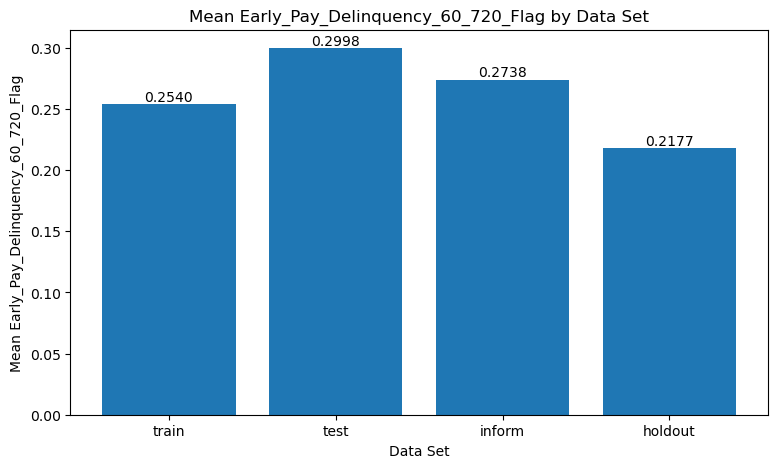

In [24]:
target_by_data_set(
    df=df,
    str_target=str_target,
)

#### Target mean by BK

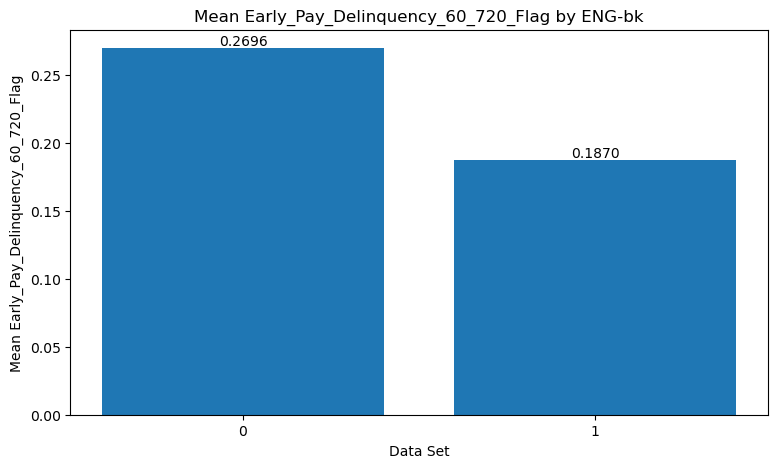

In [25]:
str_col = 'ENG-bk'
target_by_feature(
    df=df, 
    str_col=str_col,
    str_target=str_target,
)

#### Target mean by dealer type

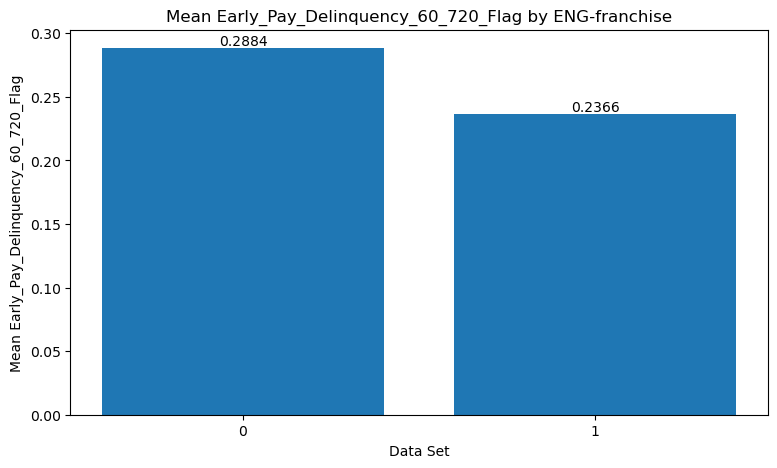

In [26]:
str_col = 'ENG-franchise'
target_by_feature(
    df=df, 
    str_col=str_col,
    str_target=str_target,
)

#### Target mean by has a codebtor

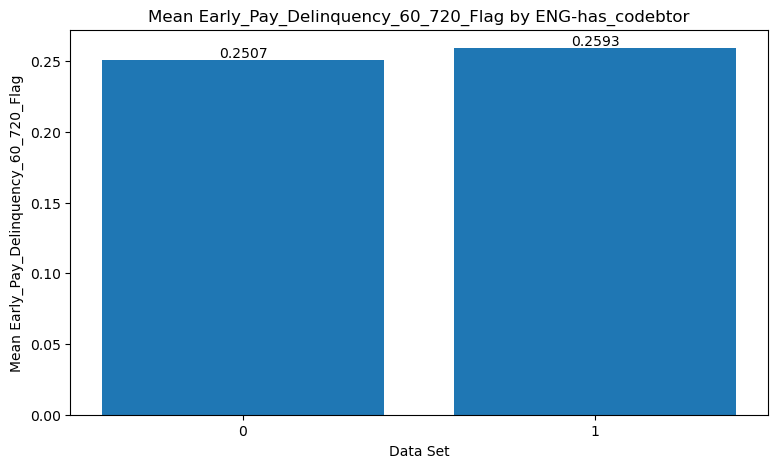

In [27]:
str_col = 'ENG-has_codebtor'
target_by_feature(
    df=df, 
    str_col=str_col,
    str_target=str_target,
)

#### Target by LTV Quantile

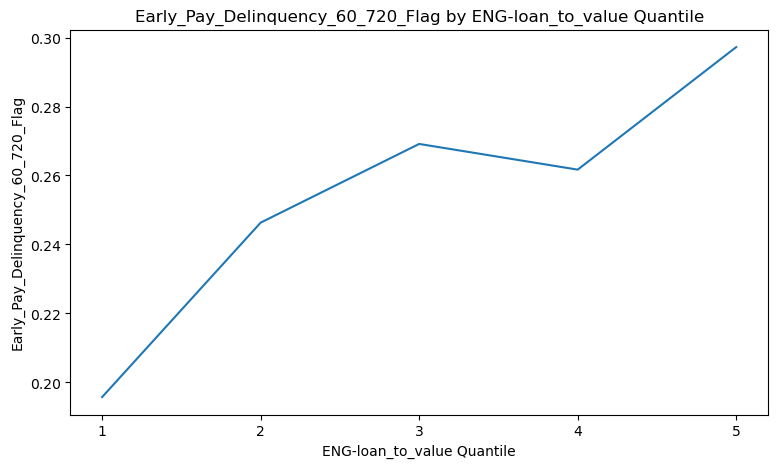

In [28]:
# get quantile
str_col = 'ENG-loan_to_value'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target=str_target,
)

#### Target by income quantile

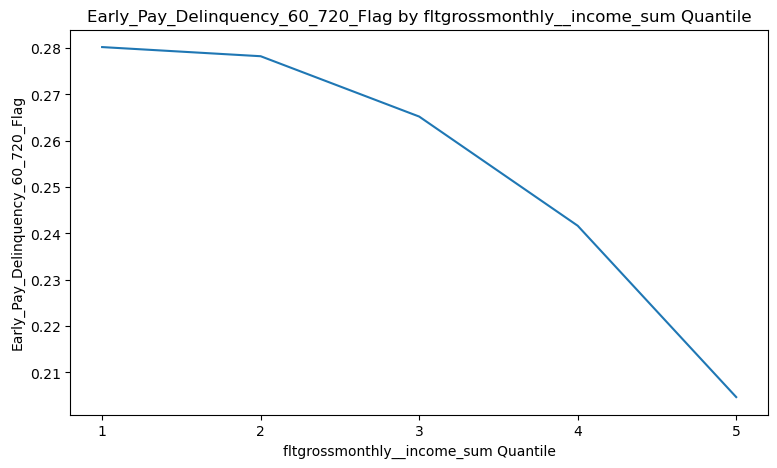

In [29]:
# get quantile
str_col = 'fltgrossmonthly__income_sum'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target=str_target,
)

#### Target by PTI Quantile

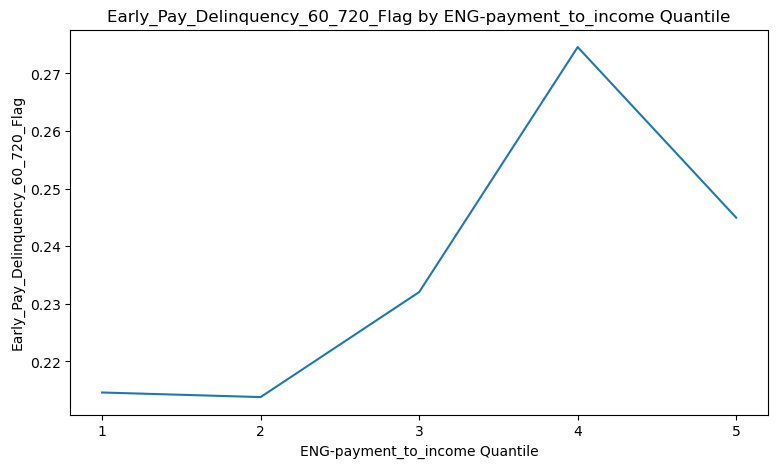

In [30]:
# get quantile
str_col = 'ENG-payment_to_income'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target=str_target,
)

#### List of columns in model

In [31]:
# list cols ignore
list_cols_ignore = [
    'uniqueid__ln',
    'biglnriskviewattributesv5id__ln',
    'bigaccountid__ln',
    'bigdebtorid__ln',
    'biglnriskviewscoreid__ln',
    'bitinvalid__ln',
    'uniqueid__app',
    'bigdebtorid__app',
    'request_datetime',
    'approvaldate__app',
    'fundeddate__app',
    'defaultdate__app',
    'chargeoffdate__app',
    'applicationdate__app',
    'run_date',
    'data_set',
    'bankruptcychapter__ln',
    'bankruptcycount24month__ln',
    'bankruptcycount__ln',
    'bankruptcydismissed24month__ln',
    'bankruptcystatus__ln',
    'bankruptcytimenewest__ln',
]
# structure
list_cols_structure = [
    'fltgrossmonthly__income_sum', # income
    'miles_odometer__app',
    'ENG-franchise',
    'ENG-has_codebtor',
    'ENG-vehicle_age', # vehicle age
    'ENG-payment_to_income', # payment to income
    'ENG-loan_to_value', # loan to value
    'ENG-bk', # bk
    'dti__app', # debt to income
]
# tu
list_cols_tu = [col for col in df.columns if '__tu' in col]
# ln
list_cols_ln = [col for col in df.columns if '__ln' in col]
# combine
list_cols_model = list_cols_structure + list_cols_tu + list_cols_ln
# rm
list_cols_model = [col for col in list_cols_model if col not in list_cols_ignore]
print(f'There are {len(list_cols_model)} features available for scorecard')

There are 2622 features available for scorecard


In [32]:
# rm for dl
list_cols_rm_dl = [
    'ENG-franchise',
    'ENG-has_codebtor',
    'ENG-bk',
]
# rm
list_cols_model = [col for col in list_cols_model if col not in list_cols_rm_dl]
# rm ln
list_cols_model = [col for col in list_cols_model if '__ln' not in col]
print(f'There are {len(list_cols_model)} starting features')

There are 2434 starting features


In [33]:
# rm non-numeric
list_cols_nonnumeric = []
for col in tqdm(list_cols_model):
    str_dtype = df[col].dtype
    if str_dtype not in ['int64','float64']:
        list_cols_nonnumeric.append(col)
    else:
        pass
print(f'There were {len(list_cols_nonnumeric)} non-numeric columns')
# rm
list_cols_model = [col for col in list_cols_model if col not in list_cols_nonnumeric]
print(f'There are {len(list_cols_model)} features available for scorecard')

100%|██████████| 2434/2434 [00:00<00:00, 16129.34it/s]

There were 63 non-numeric columns
There are 2371 features available for scorecard


In [34]:
# show the duplicates
ser_freq = pd.Series(list_cols_model).value_counts()
ser_freq = ser_freq[ser_freq > 1]
dict_freq = dict(ser_freq)
print('Duplicate Columns:')
a = 1
for key, val in dict_freq.items():
    print(f'{a}: {key}: {val}')
    a += 1
print('')
# rm dups
list_cols_model = list(dict.fromkeys(list_cols_model))
print(f'There are {len(list_cols_model)} features available for scorecard')

Duplicate Columns:

There are 2371 features available for scorecard


#### Identify all nan in training

In [35]:
df_tmp = df[df['data_set'] == 'train'].copy()
list_cols_drop = []
for col in tqdm(df.columns):
    # sample
    df_tmp_2 = df_tmp.sample(frac=0.01, random_state=42)
    flt_prop_nan = df_tmp_2[col].isnull().mean()
    # if the subsample is not 100% missing
    if flt_prop_nan < 1.0:
        continue
    else:
        # check entire sample
        flt_prop_nan = df_tmp[col].isnull().mean()
    # if its missing 100% 
    if flt_prop_nan == 1.0:
        list_cols_drop.append(col)
    else:
        pass
print(f'There were {len(list_cols_drop)} columns 100% missing in training')
list_cols_model = [col for col in list_cols_model if col not in list_cols_drop]
print(f'There are {len(list_cols_model)} features available for scorecard')
# show
#list_cols_drop

100%|██████████| 2750/2750 [00:10<00:00, 261.96it/s]

There were 657 columns 100% missing in training
There are 1730 features available for scorecard


#### Drop

In [36]:
df.drop(list_cols_drop, axis=1, inplace=True)

#### Get relationship with target in training data

In [37]:
df_tmp = df[df['data_set'] == 'train'].copy()
df_tmp = df_tmp.sample(frac=0.10, random_state=42)
int_n_quantiles = 5
df_tmp = get_suggested_constraints(
    df=df_tmp,
    list_cols_model=list_cols_model,
    str_target=str_target,
    int_n_quantiles=int_n_quantiles,
)
# map data dictionary
df_tmp['description'] = df_tmp['feature'].map(dict_map_descriptions)
# show
df_tmp

  6%|▌         | 108/1730 [00:01<00:27, 59.51it/s]


Intel oneMKL ERROR: Parameter 6 was incorrect on entry to DGELSD.


 25%|██▍       | 432/1730 [00:06<00:16, 76.90it/s]


Intel oneMKL ERROR: Parameter 6 was incorrect on entry to DGELSD.


 58%|█████▊    | 1004/1730 [00:16<00:11, 63.69it/s]


Intel oneMKL ERROR: Parameter 6 was incorrect on entry to DGELSD.

Intel oneMKL ERROR: Parameter 6 was incorrect on entry to DGELSD.


100%|██████████| 1730/1730 [00:27<00:00, 61.85it/s]


,feature,intercept,slope,constraint,imputation,description
0,fltgrossmonthly__income_sum,0.274986,-0.005605,-1,min,NaN
1,miles_odometer__app,0.194231,0.021154,1,max,NaN
2,ENG-vehicle_age,0.244644,0.006223,1,max,NaN
3,ENG-payment_to_income,0.254892,-0.002979,-1,min,NaN
4,ENG-loan_to_value,0.177073,0.027046,1,max,NaN
...,...,...,...,...,...,...
1725,flt_wtd_avg_closed__tu_pmthx,0.277778,-0.009357,-1,min,NaN
1726,flt_avg_closed__tu_pmthx,0.305182,-0.019205,-1,min,NaN
1727,int_30dpd_closed__tu_pmthx,0.294786,-0.031321,-1,min,NaN
1728,int_60dpd_closed__tu_pmthx,0.318476,-0.054476,-1,min,NaN


#### Create monotone constraints dictionary for later

In [38]:
dict_monotone_constraints = dict(zip(df_tmp['feature'], df_tmp['constraint']))

# manually alter
# dict_monotone_constraints['agg909__tu'] = 1
# dict_monotone_constraints['in57s__tu'] = -1
# dict_monotone_constraints['addrinputproblems__ln'] = 1
# dict_monotone_constraints['at34b__tu'] = -1

# save
str_filename = 'dict_monotone_constraints.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(dict_monotone_constraints, open(str_local_path, 'wb'))

# show
#dict_monotone_constraints

#### Create dictionary for imputation type

In [39]:
dict_impute_type = dict(zip(df_tmp['feature'], df_tmp['imputation']))
# create an imputation dictionary
dict_impute = {}
df_train = df[df['data_set'] == 'train'].copy()
for key, val in tqdm(dict_impute_type.items()):
    # logic
    if val == 'min':
        flt_val = df_train[key].min()
    else:
        flt_val = df_train[key].max()
    # assign
    dict_impute[key] = flt_val
    
# save
str_filename = 'dict_impute.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(dict_impute, open(str_local_path, 'wb'))

# save memory
del df_train
# show
#dict_impute

100%|██████████| 1730/1730 [00:00<00:00, 15111.62it/s]


In [40]:
# impute
for key, val in tqdm(dict_impute.items()):
    # replace any infs with nan
    df[key] = df[key].replace(np.inf, np.nan)
    # fillna
    df[key] = df[key].fillna(val)
# show
df

100%|██████████| 1730/1730 [00:01<00:00, 1015.29it/s]


,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,request_month,train,valid,test,inform,holdout,data_set
175,5716209,2021-07-30 13:53:28.0444771,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Washington,Franchise,Washington,True,...,0.003606,1.444396,0,2021-07-01,1,0,0,0,0,train
154,5702150,2021-07-30 10:22:57.8246513,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Indiana,Franchise,Indiana,True,...,0.003606,0.938360,1,2021-07-01,1,0,0,0,0,train
18,5702106,2021-07-27 12:40:50.0115498,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,California,Franchise,California,False,...,0.003606,1.347324,0,2021-07-01,1,0,0,0,0,train
207,5714824,2021-07-30 17:16:33.7898586,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,0,0,Illinois,Franchise,Illinois,False,...,0.113477,1.174497,0,2021-07-01,1,0,0,0,0,train
206,5714824,2021-07-30 17:16:33.7898586,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Franchise,Illinois,False,...,0.105172,1.174497,0,2021-07-01,1,0,0,0,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42089,6464887,2022-12-06 22:54:50+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-12-06.gzip,1,1,Illinois,Franchise,Illinois,True,...,0.003606,1.456915,1,2022-12-01,0,0,0,0,1,holdout
42197,6464638,2022-12-07 23:13:46+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-12-07.gzip,1,1,Virginia,Independent,Virginia,False,...,0.003606,1.379535,0,2022-12-01,0,0,0,0,1,holdout
41923,6464416,2022-12-03 00:37:04+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-12-02.gzip,1,1,Utah,Independent,Utah,False,...,0.167883,1.350251,0,2022-12-01,0,0,0,0,1,holdout
42062,6465473,2022-12-06 07:13:43+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-12-06.gzip,1,1,Alabama,Franchise,Alabama,False,...,0.003606,1.374376,1,2022-12-01,0,0,0,0,1,holdout


#### Show proportion missing

In [41]:
ser_isnull = df[list_cols_model].isnull().mean()
ser_isnull[ser_isnull > 0]

Series([], dtype: float64)

#### Get info from inform set

In [42]:
# get the inform data set
df_inform = df[df['data_set'] == 'inform'].copy()
# get target value
flt_target_value = df_inform[str_target].mean()
print(f'Target Value: {flt_target_value:0.4f}')

Target Value: 0.2738


#### Get train to match the inform set

In [43]:
%%time

# get the training data
df_train = df[df['data_set'] == 'train'].copy()
# get current target mean
flt_current_value = df_train[str_target].mean()
print(f'Target Value Before Sampling: {flt_current_value:0.4f}')
# init
cls_sample = OverSampling(
    df=df_train,
    str_target=str_target,
    flt_target_value=flt_target_value,
    flt_current_value=flt_current_value,
)
# sample
df_train = cls_sample.sample()
# get current target mean
flt_current_value = df_train[str_target].mean()
print(f'Target Value After Sampling: {flt_current_value:0.4f}')
print()
# show
df_train

Target Value Before Sampling: 0.2540
Target Value After Sampling: 0.2739

CPU times: user 659 ms, sys: 269 ms, total: 928 ms
Wall time: 926 ms


,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,request_month,train,valid,test,inform,holdout,data_set
11907,5923735,2022-02-17 23:51:18+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-02-17.gzip,0,0,Florida,Independent,Florida,True,...,0.075953,1.064734,0,2022-02-01,0,1,0,0,0,train
9073,5876750,2021-12-29 02:52:19+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2021-12-28.gzip,0,0,Georgia,Franchise,Georgia,True,...,0.074969,1.281146,0,2021-12-01,1,0,0,0,0,train
102,5706177,2021-07-29 11:06:12.1747017,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Franchise,Illinois,True,...,0.003606,1.268964,0,2021-07-01,1,0,0,0,0,train
14833,5965992,2022-03-24 23:41:29+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-03-24.gzip,0,0,Illinois,Franchise,Illinois,True,...,0.003606,1.346716,0,2022-03-01,0,1,0,0,0,train
2705,5765640,2021-10-05 23:47:00+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2021-10-05.gzip,0,0,Pennsylvania,Franchise,Pennsylvania,True,...,0.093411,1.203647,0,2021-10-01,1,0,0,0,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7505,5824028,2021-12-01 03:55:18+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2021-11-30.gzip,1,1,Illinois,Franchise,Illinois,True,...,0.003606,1.453867,0,2021-12-01,1,0,0,0,0,train
6332,5828024,2021-11-14 06:36:00+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2021-11-13.gzip,0,0,Utah,Franchise,Utah,True,...,0.144669,1.523242,0,2021-11-01,1,0,0,0,0,train
890,5709926,2021-08-24 16:29:32.1145307,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Utah,Franchise,Utah,False,...,0.049454,1.155960,0,2021-08-01,1,0,0,0,0,train
3295,5760680,2021-10-12 03:08:24+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2021-10-11.gzip,1,1,Georgia,Franchise,Georgia,False,...,0.003606,1.078610,1,2021-10-01,1,0,0,0,0,train


#### Get test to match the inform set


In [44]:
%%time

df_test = df[df['data_set'] == 'test'].copy()
# get current target mean
flt_current_value = df_test[str_target].mean()
print(f'Target Value Before Sampling: {flt_current_value:0.4f}')
# init
cls_sample = OverSampling(
    df=df_test,
    str_target=str_target,
    flt_target_value=flt_target_value,
    flt_current_value=flt_current_value,
)
# sample
df_test = cls_sample.sample()
# get current target mean
flt_current_value = df_test[str_target].mean()
print(f'Target Value After Sampling: {flt_current_value:0.4f}')
print()
# show
df_test

Target Value Before Sampling: 0.2998
Target Value After Sampling: 0.2738

CPU times: user 520 ms, sys: 168 ms, total: 688 ms
Wall time: 687 ms


,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,request_month,train,valid,test,inform,holdout,data_set
17439,6012614,2022-04-19 21:42:08+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-04-19.gzip,1,1,California,Franchise,California,True,...,0.056094,1.451999,0,2022-04-01,0,0,1,0,0,test
26952,6162319,2022-07-22 03:52:09+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-07-21.gzip,1,1,Oklahoma,Independent,Oklahoma,True,...,0.166955,1.128369,1,2022-07-01,0,0,1,0,0,test
24565,6122326,2022-06-27 22:16:55+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-06-27.gzip,1,1,Indiana,Independent,Michigan,False,...,0.003606,1.238542,0,2022-06-01,0,0,1,0,0,test
15775,5951280,2022-04-01 23:38:09+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-04-01.gzip,1,1,Colorado,Franchise,Colorado,True,...,0.003606,1.188877,0,2022-04-01,0,0,1,0,0,test
17044,5998301,2022-04-14 23:28:44+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-04-14.gzip,1,1,Illinois,Independent,Illinois,True,...,0.003606,1.380299,0,2022-04-01,0,0,1,0,0,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26124,6152457,2022-07-13 05:13:35+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-07-12.gzip,0,0,Texas,Franchise,Texas,False,...,0.003606,1.201161,0,2022-07-01,0,0,1,0,0,test
23870,6125573,2022-06-21 05:43:13+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-06-20.gzip,1,1,Illinois,Independent,Illinois,True,...,0.003606,1.305745,0,2022-06-01,0,0,1,0,0,test
24590,6129815,2022-06-27 23:04:17+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-06-27.gzip,1,1,Indiana,Independent,Indiana,True,...,0.003606,1.300000,0,2022-06-01,0,0,1,0,0,test
18312,6029481,2022-04-27 00:45:32+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-04-26.gzip,1,1,Virginia,Franchise,Virginia,False,...,0.084306,1.209549,0,2022-04-01,0,0,1,0,0,test


#### List of columns to start

In [45]:
print(f'Starting with {len(list_cols_model)} features:')
# for a, col in enumerate(list_cols_model_original):
#     print(f'{a+1}: {col}')

Starting with 1730 features:


#### Split into X and y

In [46]:
# train
X_train = df_train[list_cols_model]
y_train = df_train[str_target]
# save memory
del df_train

In [47]:
# test
X_test = df_test[list_cols_model]
y_test = df_test[str_target]
# save memory
del df_test

In [48]:
# holdout
X_holdout = df[df['data_set'] == 'holdout'][list_cols_model].copy()
y_holdout = df[df['data_set'] == 'holdout'][str_target]
# save memory
del df

#### Monotone constraints

In [49]:
#dict_monotone_constraints

#### Bin features

In [50]:
dict_bins, list_cols_scorecard, X_train, X_test, X_holdout = bin_features(
    list_cols=list_cols_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    X_holdout=X_holdout,
    dict_monotone_constraints=dict_monotone_constraints,
)
# pickle dict_bins
str_filename = 'dict_bins.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(dict_bins, open(str_local_path, 'wb'))

100%|██████████| 1730/1730 [00:26<00:00, 65.09it/s]


In [51]:
# make sure every column has at least 2 bins
list_col_no_var = []
for col in tqdm(list_cols_scorecard):
    int_n_unique = X_train[col].nunique()
    # logic
    if int_n_unique < 2:
        list_col_no_var.append(col)
    else:
        pass
print(f'There are {len(list_col_no_var)} features with no variance after binning')
# rm
list_cols_scorecard = [col for col in list_cols_scorecard if col not in list_col_no_var]
print(f'There are {len(list_cols_scorecard)} features available for scorecard inclusion')

100%|██████████| 1730/1730 [00:00<00:00, 4188.26it/s]


There are 541 features with no variance after binning
There are 1189 features available for scorecard inclusion


In [52]:
# show bins
df_tmp = X_train.copy()
df_tmp['target'] = y_train
list_df = []
for col in tqdm(list_cols_scorecard):
    # get original column
    str_col_original = col.split('_binned')[0]
    # get min max and mean
    df_grouped = df_tmp.groupby(by=col, as_index=False).agg({
        str_col_original: ['min', 'max', 'count'],
        'target': 'mean',
    })
    # sort
    df_grouped.sort_values(by=(str_col_original, 'min'), ascending=True, inplace=True)
    df_grouped['feature'] = col
    # rename
    list_cols = ['bin','min','max','count','target','feature']
    df_grouped.columns = list_cols
    df_grouped['prop'] = df_grouped['count'] / df_grouped['count'].sum()
    # bin label
    df_grouped['bin_label'] = range(1, df_grouped.shape[0]+1)
    # reorder
    list_cols = ['feature','bin','min','max','count','prop','target','bin_label']
    df_grouped = df_grouped[list_cols].copy()
    # append
    list_df.append(df_grouped)
    
    #print(f'{a+1} - {str_col_original}')
    #print(df_grouped)
    #print()

# make df
df_bins = pd.concat(list_df)

# save
str_filename = 'df_bins.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_bins.to_csv(str_local_path, index=False)

# show
df_bins

100%|██████████| 1189/1189 [00:06<00:00, 180.78it/s]


,feature,bin,min,max,count,prop,target,bin_label
0,fltgrossmonthly__income_sum_binned,-0.150552,0.0,2771.0,3507,0.218695,0.304819,1
1,fltgrossmonthly__income_sum_binned,-0.141610,2772.0,3243.0,2357,0.146982,0.302927,2
2,fltgrossmonthly__income_sum_binned,-0.100720,3244.0,3645.0,1916,0.119481,0.294363,3
3,fltgrossmonthly__income_sum_binned,-0.039656,3646.0,3967.0,1217,0.075892,0.281841,4
4,fltgrossmonthly__income_sum_binned,0.050967,3968.0,4880.0,2975,0.185520,0.263866,5
...,...,...,...,...,...,...,...,...
1,int_30dpd_closed__tu_pmthx_binned,0.308792,5.0,42.0,982,0.061237,0.216904,2
0,int_60dpd_closed__tu_pmthx_binned,-0.004853,0.0,1.0,14990,0.934772,0.274850,1
1,int_60dpd_closed__tu_pmthx_binned,0.070763,2.0,34.0,1046,0.065228,0.260038,2
1,int_90dpd_closed__tu_pmthx_binned,0.134773,0.0,0.0,7184,0.447992,0.247912,1


#### Get feature importance from catboost model

In [53]:
list_cols_model = [col.split('_binned')[0] for col in list_cols_scorecard]
# pool data
pool_train = cb.Pool(
    X_train[list_cols_model].copy(), 
    y_train, 
)
# pool
pool_valid = cb.Pool(
    X_test[list_cols_model].copy(), 
    y_test, 
)
# init class
cls_model_inference = cb.CatBoostClassifier(
    task_type='CPU',
    nan_mode='Min',
    random_state=42,
    eval_metric='AUC',
    iterations=int_n_iterations,
    learning_rate=None,
    class_weights=None,
    depth=int_max_depth,
)
# fit
cls_model_inference.fit(
    pool_train,
    eval_set=[pool_valid],
    verbose=False,
    use_best_model=True,
    early_stopping_rounds=int_n_early_stopping, 
)
# get importance
df_tmp = get_catboost_feat_importance(
    cls_model_inference=cls_model_inference,
    pool_eval=pool_valid,
)
# make dictionary
dict_map_importance = dict(zip(df_tmp['feature'], df_tmp['importance']))
# show
df_tmp

,feature,importance
0,dti__app,0.008689
1,ENG-loan_to_value,0.001079
2,balmag01__tu,0.001075
3,int_n_months_open__tu_pmthx,0.000666
4,s004s__tu,0.000571
...,...,...
389,s207s__tu,0.000000
398,g244b__tu,0.000000
1186,linkt007__tu,-0.000011
1187,g213a__tu,-0.000041


#### Check for multicollinearity

In [54]:
# find multicollinear columns
df_tmp = X_train.sample(frac=0.01, random_state=42)
df_tmp, list_cols_remove = remove_multicollinearity(
    X=df_tmp, 
    list_cols_model=list_cols_model, 
    dict_map_importance=dict_map_importance, 
    flt_threshold=flt_threshold,
)
# add binned suffix
list_cols_remove = [f'{col}_binned' for col in list_cols_remove]
print('Columns to Remove:')
for a, col in enumerate(list_cols_remove):
    print(f'{a+1} - {col}')
print()
# show
df_tmp

100%|██████████| 1189/1189 [16:10<00:00,  1.22it/s]


Columns to Remove:
1 - ENG-payment_to_income_binned
2 - linkt004__tu_binned
3 - linkt007__tu_binned
4 - linkt006__tu_binned
5 - g099a__tu_binned
6 - linkt008__tu_binned
7 - linkt009__tu_binned
8 - linkt010__tu_binned
9 - at01s__tu_binned
10 - at02s__tu_binned
11 - at03s__tu_binned
12 - at09s__tu_binned
13 - at12s__tu_binned
14 - at20s__tu_binned
15 - at24s__tu_binned
16 - at25s__tu_binned
17 - at27s__tu_binned
18 - at28a__tu_binned
19 - at28b__tu_binned
20 - at29s__tu_binned
21 - at30s__tu_binned
22 - at32s__tu_binned
23 - at33a__tu_binned
24 - at33b__tu_binned
25 - at34a__tu_binned
26 - at34b__tu_binned
27 - at35a__tu_binned
28 - at35b__tu_binned
29 - at36s__tu_binned
30 - at57s__tu_binned
31 - at101s__tu_binned
32 - at101b__tu_binned
33 - at104s__tu_binned
34 - au01s__tu_binned
35 - au02s__tu_binned
36 - au03s__tu_binned
37 - au06s__tu_binned
38 - au09s__tu_binned
39 - au12s__tu_binned
40 - au21s__tu_binned
41 - au20s__tu_binned
42 - g307s__tu_binned
43 - au200s__tu_binned
44 - int_n

,col1,col2,r,r_abs,col1_importance,col2_importance,high_correlation,remove_feature
3602,ENG-payment_to_income,au03s__tu,0.789123,0.789123,0.0,0.0,1,ENG-payment_to_income
3605,ENG-payment_to_income,au12s__tu,-0.917539,0.917539,0.0,0.0,1,ENG-payment_to_income
3608,ENG-payment_to_income,au24s__tu,-0.790937,0.790937,0.0,0.0,1,ENG-payment_to_income
3611,ENG-payment_to_income,au28s__tu,0.910251,0.910251,0.0,0.0,1,ENG-payment_to_income
3612,ENG-payment_to_income,au29s__tu,-0.917539,0.917539,0.0,0.0,1,ENG-payment_to_income
...,...,...,...,...,...,...,...,...
706255,int_n_months_closed__tu_pmthx,int_90dpd_closed__tu_pmthx,-0.783943,0.783943,0.0,0.0,1,int_n_months_closed__tu_pmthx
706256,flt_wtd_avg_closed__tu_pmthx,flt_avg_closed__tu_pmthx,0.997025,0.997025,0.0,0.0,1,flt_wtd_avg_closed__tu_pmthx
706259,flt_wtd_avg_closed__tu_pmthx,int_90dpd_closed__tu_pmthx,-0.857854,0.857854,0.0,0.0,1,flt_wtd_avg_closed__tu_pmthx
706262,flt_avg_closed__tu_pmthx,int_90dpd_closed__tu_pmthx,-0.864567,0.864567,0.0,0.0,1,flt_avg_closed__tu_pmthx


#### Baseline model

There are 139 features available for scorecard inclusion


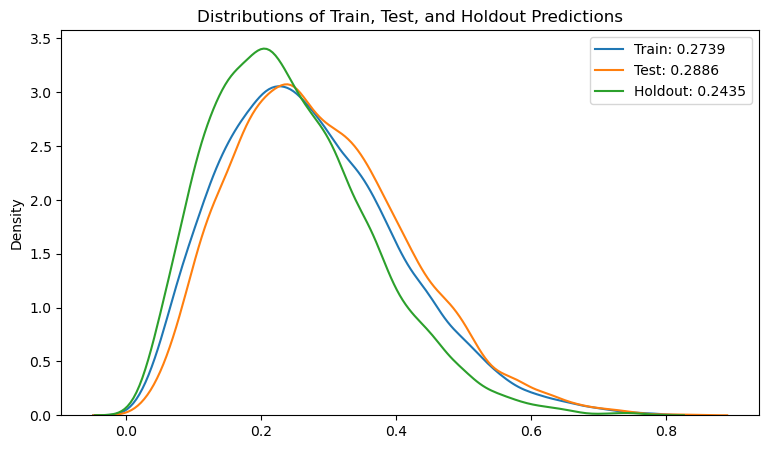

In [55]:
# rm collinear
list_cols_scorecard = [col for col in list_cols_scorecard if col not in list_cols_remove]
print(f'There are {len(list_cols_scorecard)} features available for scorecard inclusion')

# init
cls_model_inference = LogisticRegression(
    random_state=42,
    fit_intercept=True,
)
# fit
cls_model_inference.fit(
    X_train[list_cols_scorecard],
    y_train,
)

# get predictions
list_predictions_train = list(cls_model_inference.predict_proba(X_train[list_cols_scorecard])[:,1])
list_predictions_test = list(cls_model_inference.predict_proba(X_test[list_cols_scorecard])[:,1])
list_predictions_holdout = list(cls_model_inference.predict_proba(X_holdout[list_cols_scorecard])[:,1])

# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Train, Test, and Holdout Predictions')
sns.kdeplot(list_predictions_train, label=f'Train: {np.mean(list_predictions_train):0.4f}')
sns.kdeplot(list_predictions_test, label=f'Test: {np.mean(list_predictions_test):0.4f}')
sns.kdeplot(list_predictions_holdout, label=f'Holdout: {np.mean(list_predictions_holdout):0.4f}')
# legend
ax.legend()
# show
plt.show()

In [56]:
# eval
flt_auc_train, flt_auc_test = evaluate(
    y_train=y_train,
    list_predictions_train=list_predictions_train,
    y_test=y_test,
    list_predictions_test=list_predictions_test,
    y_holdout=y_holdout,
    list_predictions_holdout=list_predictions_holdout,
)

AUC Train: 0.6869
AUC Test: 0.6461
AUC Holdout: 0.6446

Logloss Train: 0.5413
Logloss Test: 0.5613
Logloss Holdout: 0.5038

KS Train: 0.2710
KS Test: 0.2118
KS Holdout: 0.2103


#### Sensitivity tuning

In [57]:
# starting target
flt_auc_train_start = flt_auc_test
# make copy
list_cols_start = list_cols_scorecard.copy()

list_feat_rm = []
list_dict_row_a = []
while True:
    list_dict_row_b = []
    # make sure the features have been removed
    list_cols_start = [col for col in list_cols_start if col not in list_feat_rm]
    # iterate through cols and remove one at a time with replacement
    for col_a in tqdm(list_cols_start):
        # rm col
        list_cols_scorecard_tmp = [col_b for col_b in list_cols_start if col_b != col_a]

        # init
        cls_model_inference = LogisticRegression(
            random_state=42,
            fit_intercept=True,
        )
        # fit
        cls_model_inference.fit(
            X_train[list_cols_scorecard_tmp].copy(),
            y_train,
        )

        # get predictions
        #list_predictions_tmp = list(cls_model_inference.predict_proba(X_train[list_cols_scorecard_tmp])[:,1])
        list_predictions_tmp = list(cls_model_inference.predict_proba(X_test[list_cols_scorecard_tmp])[:,1])

        # get auc
        flt_score = skm.roc_auc_score(
            y_true=y_test,
            y_score=list_predictions_tmp,
        )
        # make row
        dict_row_b = {
            'feature': col_a,
            'score': flt_score,
            'target': flt_auc_train_start,
        }
        # append
        list_dict_row_b.append(dict_row_b)
    # make df
    df_tmp = pd.DataFrame(list_dict_row_b)
    
    # get diff
    df_tmp['diff'] = df_tmp['score'] - df_tmp['target']
    
    # make a copy
    df_sensitivity = df_tmp.copy()
    # sort
    df_sensitivity.sort_values(by='diff', ascending=True, inplace=True)
    # save
    str_filename = 'df_sensitivity.csv'
    str_local_path = f'{str_dirname_output}/{str_filename}'
    df_sensitivity.to_csv(str_local_path, index=False)
    
    # only keep positive
    df_tmp = df_tmp[df_tmp['diff'] >= 0].copy()
    
    # get number of features that improved performance upon removal
    int_n_feats = df_tmp.shape[0]
    
    # logic
    if int_n_feats == 0:
        break
    else:
        pass
    
    # sort
    df_tmp.sort_values(by='diff', ascending=False, inplace=True)
    # get the feature that improves performance most upon removal
    str_feat_rm = df_tmp['feature'].iloc[0]
    # append
    list_feat_rm.append(str_feat_rm)
    # get score
    flt_score_rm = df_tmp['score'].iloc[0]
    # update the flt_auc_train_start
    flt_auc_train_start = flt_score_rm
    # get current target
    flt_target_rm = df_tmp['target'].iloc[0]
    # make row
    dict_row_a = {
        'feature': str_feat_rm,
        'score': flt_score_rm,
        'target': flt_target_rm,
    }
    # append
    list_dict_row_a.append(dict_row_a)
# make df
df_tmp = pd.DataFrame(list_dict_row_a)
# save
str_filename = 'df_sensitivity_tuning.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_csv(str_local_path, index=False)
# show
df_tmp

100%|██████████| 94/94 [00:07<00:00, 12.24it/s]


,feature,score,target
0,of36s__tu_binned,0.647379,0.646112
1,trv21__tu_binned,0.648637,0.647379
2,agg319__tu_binned,0.649340,0.648637
3,agg224__tu_binned,0.649956,0.649340
4,trv09__tu_binned,0.650476,0.649956
5,paymnt06__tu_binned,0.650772,0.650476
6,fltgrossmonthly__income_sum_binned,0.651035,0.650772
7,linkf213__tu_binned,0.651394,0.651035
8,aut231__tu_binned,0.651667,0.651394
9,linkb010__tu_binned,0.651930,0.651667


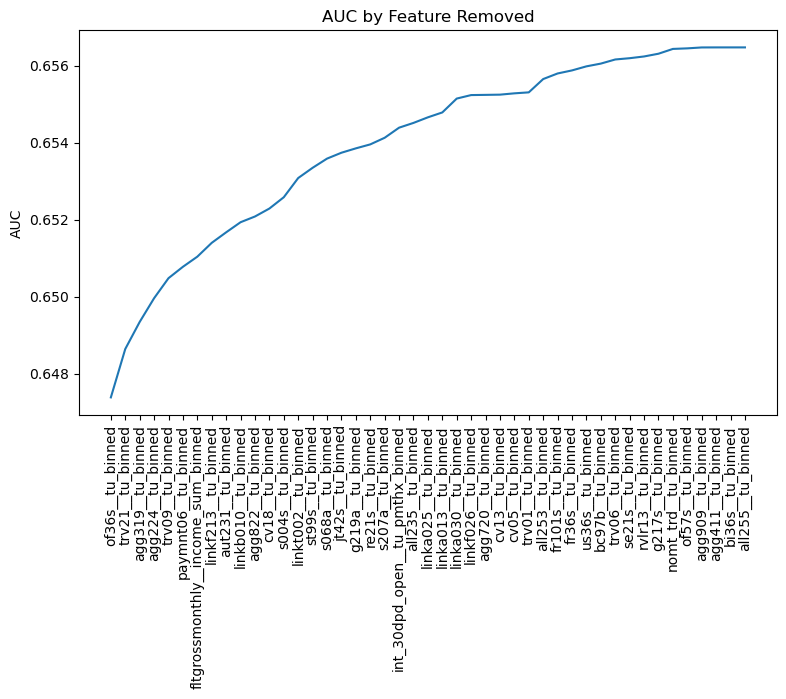

In [58]:
# plot
x = df_tmp['feature']
y = df_tmp['score']
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('AUC by Feature Removed')
ax.set_ylabel('AUC')
ax.plot(x, y)
ax.set_xticklabels(x, rotation=90)
plt.show()

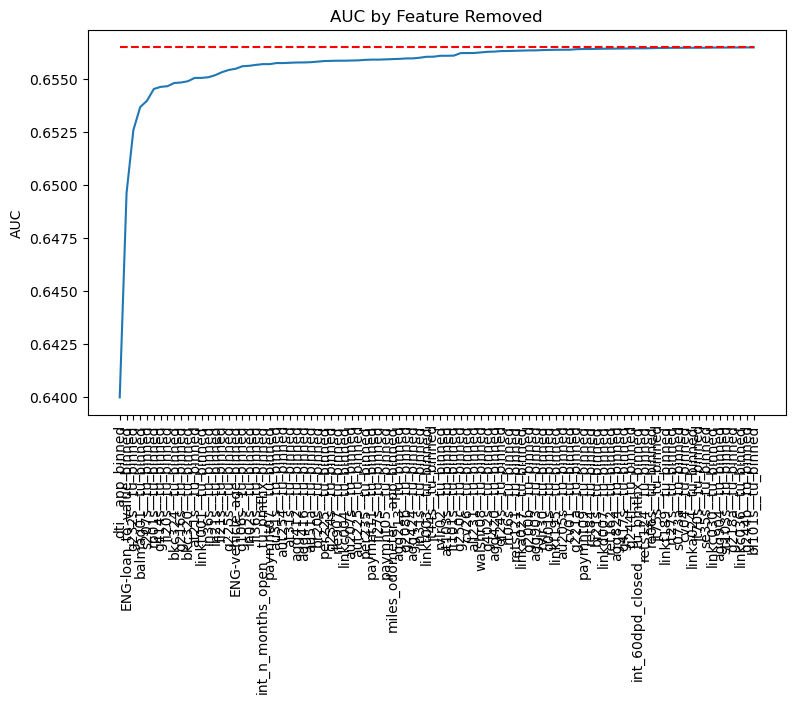

In [59]:
# plot
x = df_sensitivity['feature']
y = df_sensitivity['score']
z = df_sensitivity['target']
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('AUC by Feature Removed')
ax.set_ylabel('AUC')
ax.plot(x, y)
ax.plot(x, z, linestyle='--', color='red')
ax.set_xticklabels(x, rotation=90)
plt.show()

There are 94 features in the scorecard


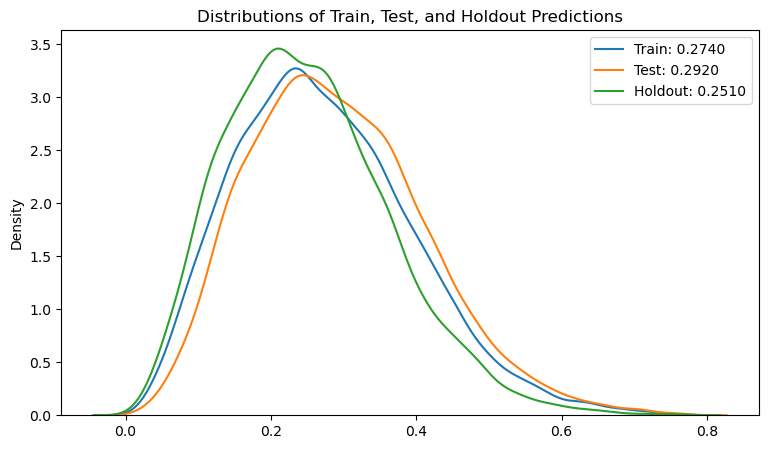

In [60]:
# rm
list_cols_rm = list(df_tmp['feature'])
list_cols_scorecard = [col for col in list_cols_scorecard if col not in list_cols_rm]
print(f'There are {len(list_cols_scorecard)} features in the scorecard')

# init
cls_model_inference = LogisticRegression(
    random_state=42,
    fit_intercept=True,
)
# fit
cls_model_inference.fit(
    X_train[list_cols_scorecard].copy(),
    y_train,
)

# save
str_filename = 'cls_model_inference_ml_logistic_scorecard.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(cls_model_inference, open(str_local_path, 'wb'))

# get predictions
list_predictions_train = list(cls_model_inference.predict_proba(X_train[list_cols_scorecard])[:,1])
list_predictions_test = list(cls_model_inference.predict_proba(X_test[list_cols_scorecard])[:,1])
list_predictions_holdout = list(cls_model_inference.predict_proba(X_holdout[list_cols_scorecard])[:,1])

# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Train, Test, and Holdout Predictions')
sns.kdeplot(list_predictions_train, label=f'Train: {np.mean(list_predictions_train):0.4f}')
sns.kdeplot(list_predictions_test, label=f'Test: {np.mean(list_predictions_test):0.4f}')
sns.kdeplot(list_predictions_holdout, label=f'Holdout: {np.mean(list_predictions_holdout):0.4f}')
# legend
ax.legend()
# show
plt.show()

In [61]:
# eval
flt_auc_train, flt_auc_test = evaluate(
    y_train=y_train,
    list_predictions_train=list_predictions_train,
    y_test=y_test,
    list_predictions_test=list_predictions_test,
    y_holdout=y_holdout,
    list_predictions_holdout=list_predictions_holdout,
)

AUC Train: 0.6745
AUC Test: 0.6565
AUC Holdout: 0.6432

Logloss Train: 0.5472
Logloss Test: 0.5562
Logloss Holdout: 0.5038

KS Train: 0.2513
KS Test: 0.2220
KS Holdout: 0.1903


#### Get intercept

In [62]:
# get intercept
flt_intercept = cls_model_inference.intercept_[0]
print(f'Intercept: {flt_intercept}')

Intercept: -0.9746132904648355


In [63]:
# get feature importance
dict_map_descriptions_bin = {f'{key}_binned': val for key, val in dict_map_descriptions.items()}
df_tmp = get_logistic_regression_feat_importance(
    cls_model_inference=cls_model_inference,
    list_cols_model=list_cols_scorecard,
    df=X_test,
)
# map desceription
df_tmp['description'] = df_tmp['feature'].map(dict_map_descriptions_bin)

# save
str_filename = 'df_feat_imp.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_csv(str_local_path, index=False)

# show
df_tmp

,feature,importance,importance_abs,description
91,linkc004__tu_binned,0.032831,0.032831,Number of unpaid payday loan charge-offs in th...
37,s207s__tu_binned,0.012767,0.012767,Months since most recent public record bankruptcy
3,dti__app_binned,0.010397,0.010397,NaN
4,linkt001__tu_binned,-0.007948,0.007948,Number of non-military addresses in last 7 years
0,miles_odometer__app_binned,0.007297,0.007297,NaN
...,...,...,...,...
21,g218a__tu_binned,0.000004,0.000004,Number of trades verified in the past 12 month...
40,g244b__tu_binned,-0.000003,0.000003,Number of bank inquiries (includes duplicates)...
80,paymnt05__tu_binned,0.000003,0.000003,Total amount of prepayments on installment loa...
42,se35s__tu_binned,-0.000003,0.000003,Average balance of open secured installment tr...


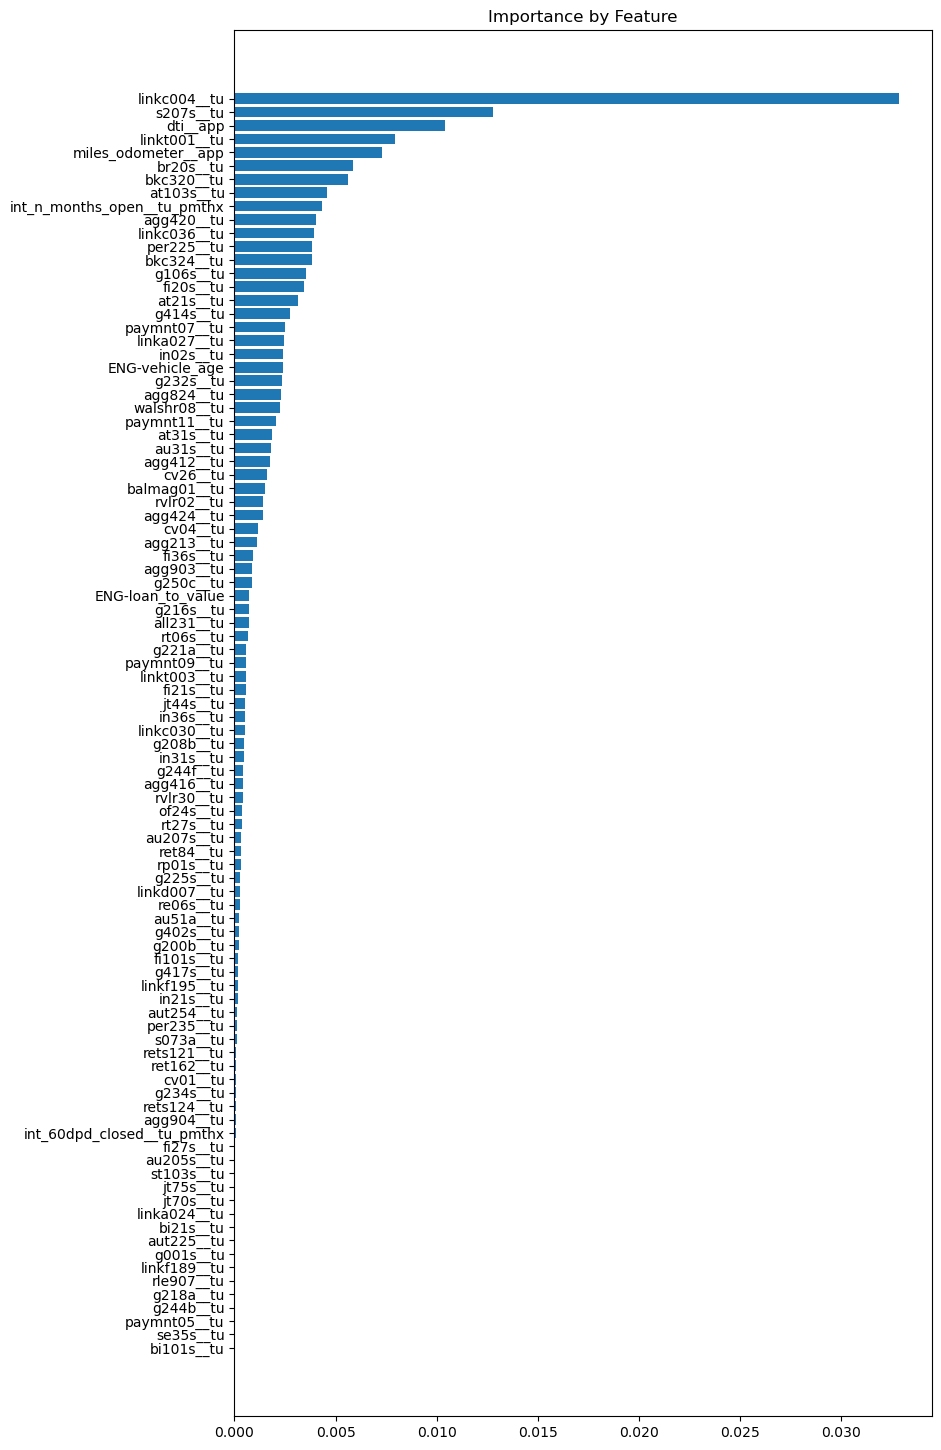

In [64]:
# plot
df_tmp.sort_values(by='importance_abs', ascending=True, inplace=True)
df_tmp['feature_tmp'] = df_tmp['feature'].apply(
    lambda x: x.split('_binned')[0],
)
x = df_tmp['feature_tmp']
y = df_tmp['importance_abs']
fig, ax = plt.subplots(figsize=(9,18))
ax.set_title('Importance by Feature')
ax.barh(x, y)
# show
plt.show()

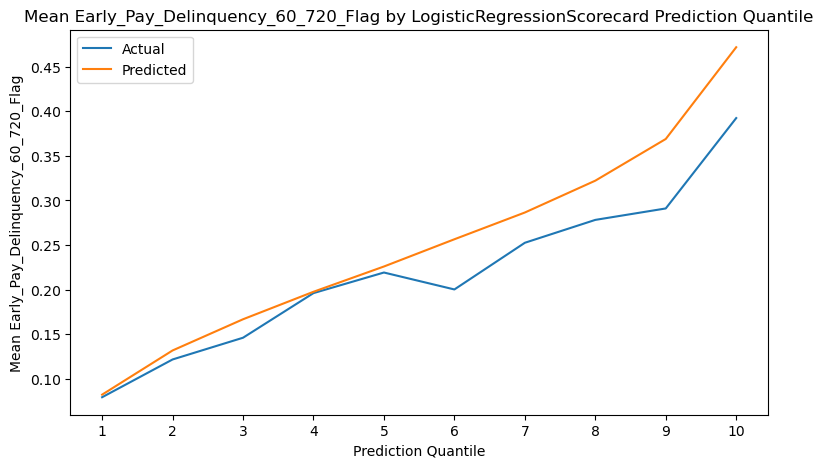

In [65]:
# mean actual by prediction quantile
int_n_quantiles = 10
get_mean_actual_by_prediction_quantile(
    X=X_holdout.copy(),
    list_predictions=list_predictions_holdout,
    list_actual=list(y_holdout),
    str_target=str_target,
    int_n_quantiles=int_n_quantiles,
    str_model_type='LogisticRegressionScorecard',
)

  0%|          | 0/94 [00:00<?, ?it/s]

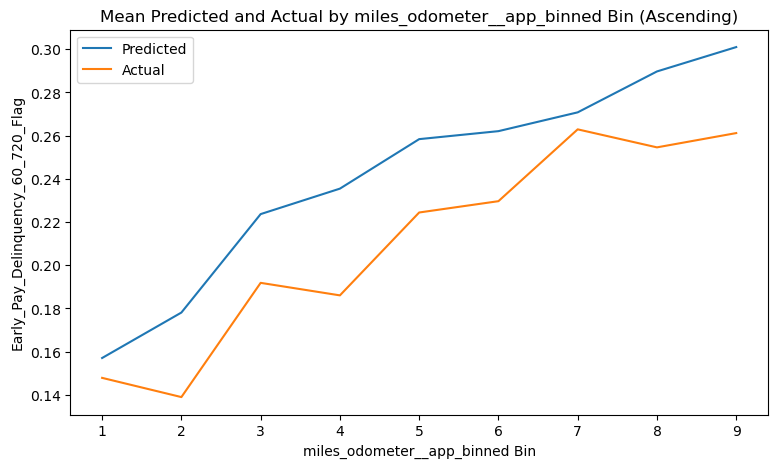

  1%|          | 1/94 [00:00<00:15,  5.94it/s]

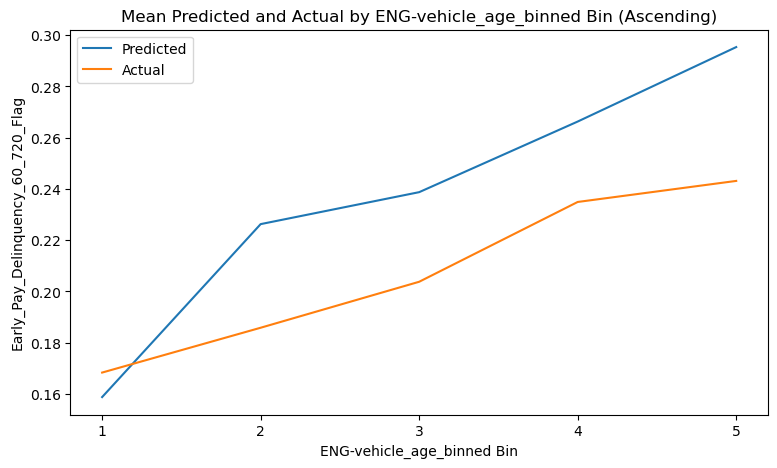

  2%|▏         | 2/94 [00:00<00:14,  6.34it/s]

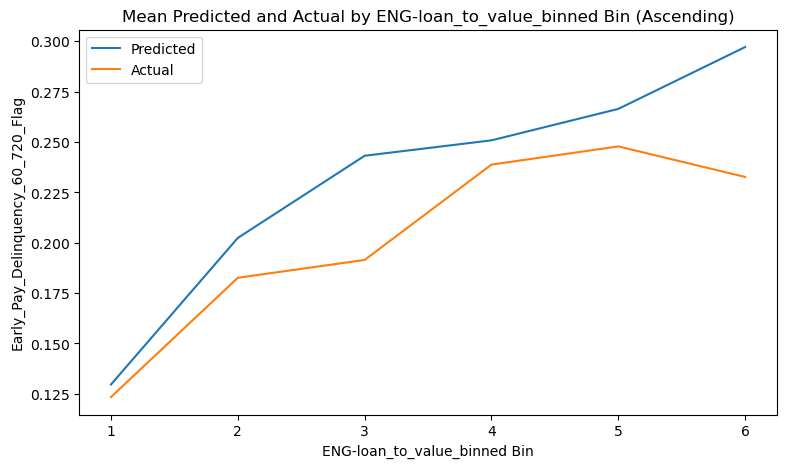

  3%|▎         | 3/94 [00:00<00:14,  6.37it/s]

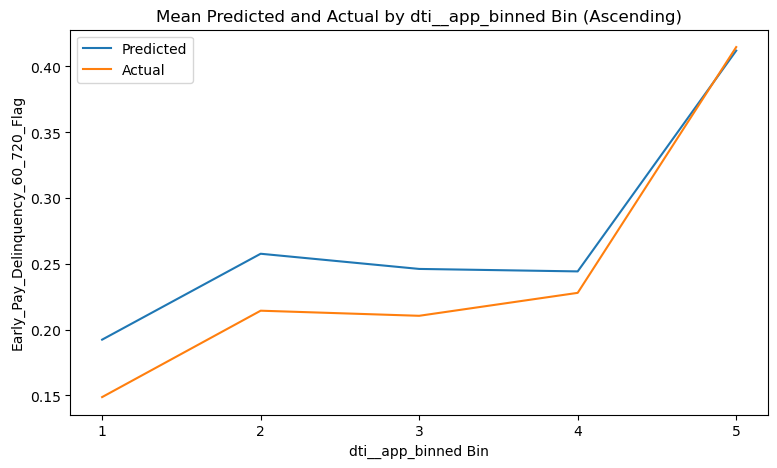

  4%|▍         | 4/94 [00:00<00:13,  6.62it/s]

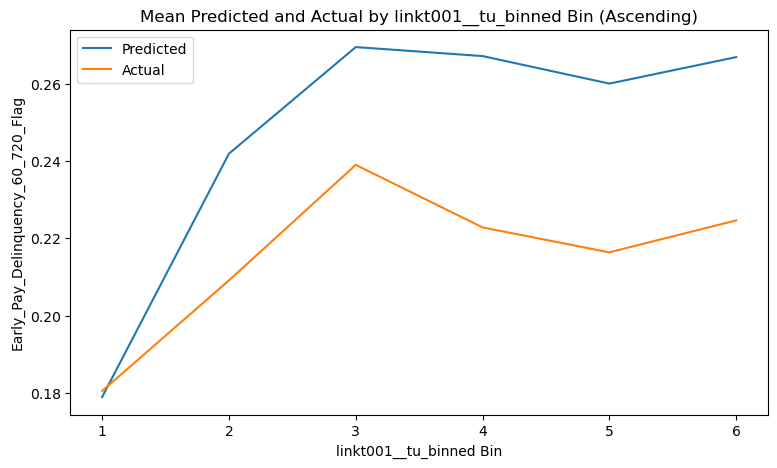

  5%|▌         | 5/94 [00:00<00:13,  6.77it/s]

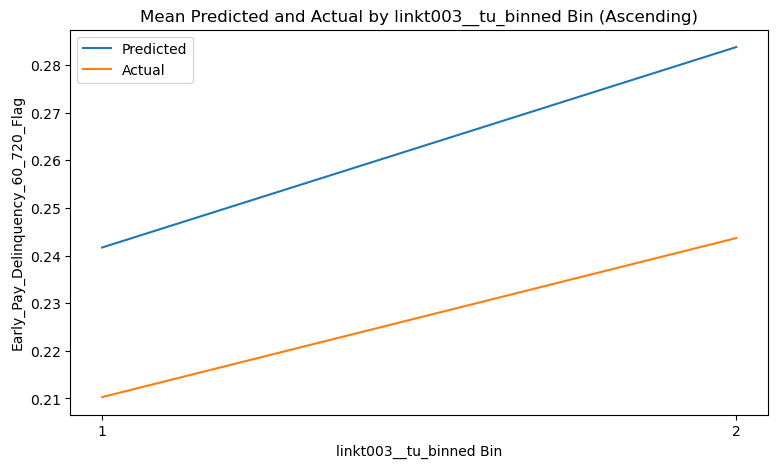

  6%|▋         | 6/94 [00:00<00:12,  6.88it/s]

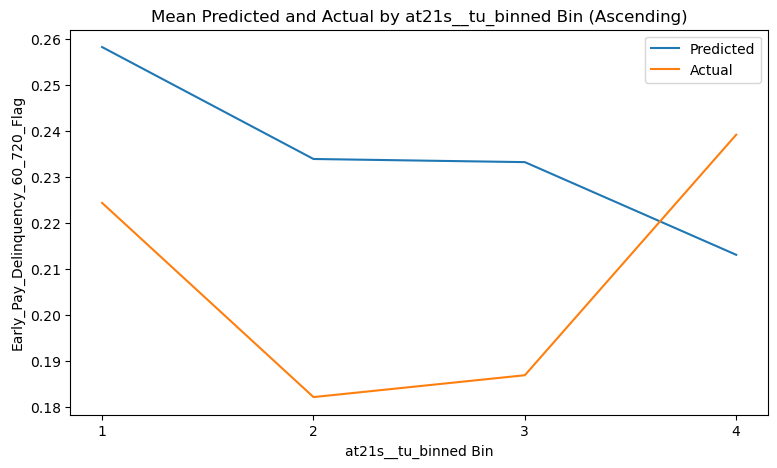

  7%|▋         | 7/94 [00:01<00:12,  6.73it/s]

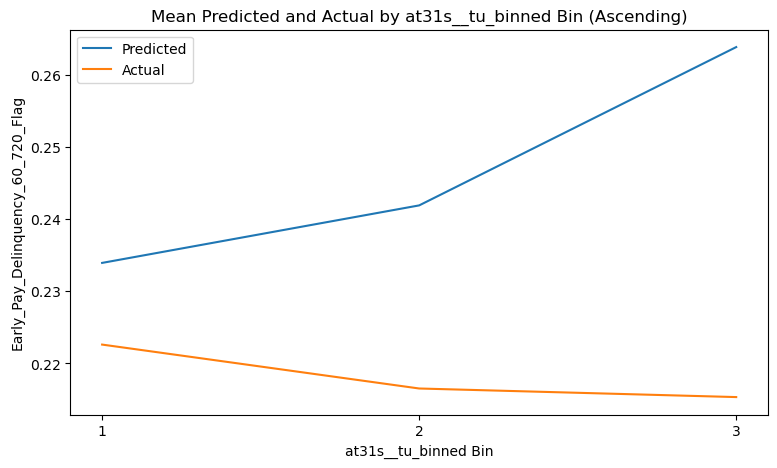

  9%|▊         | 8/94 [00:01<00:12,  7.01it/s]

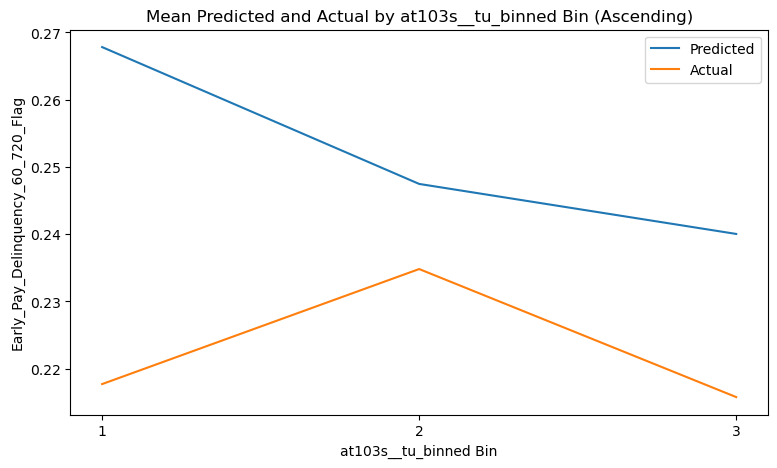

 10%|▉         | 9/94 [00:01<00:11,  7.12it/s]

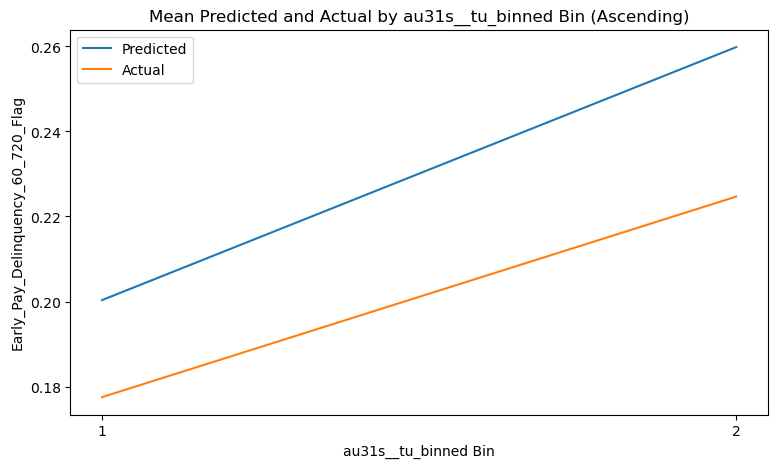

 11%|█         | 10/94 [00:01<00:11,  7.34it/s]

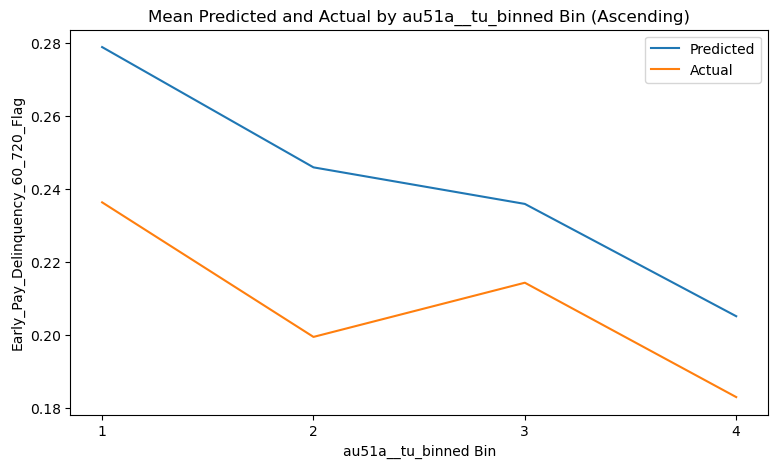

 12%|█▏        | 11/94 [00:01<00:11,  7.34it/s]

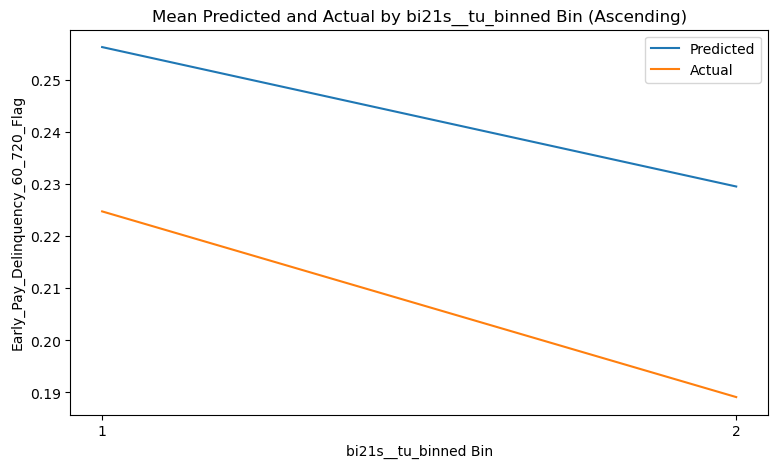

 13%|█▎        | 12/94 [00:01<00:16,  5.02it/s]

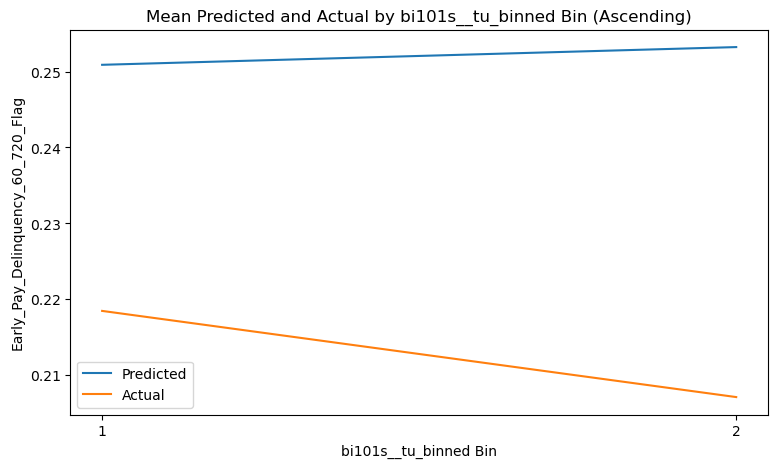

 14%|█▍        | 13/94 [00:02<00:14,  5.63it/s]

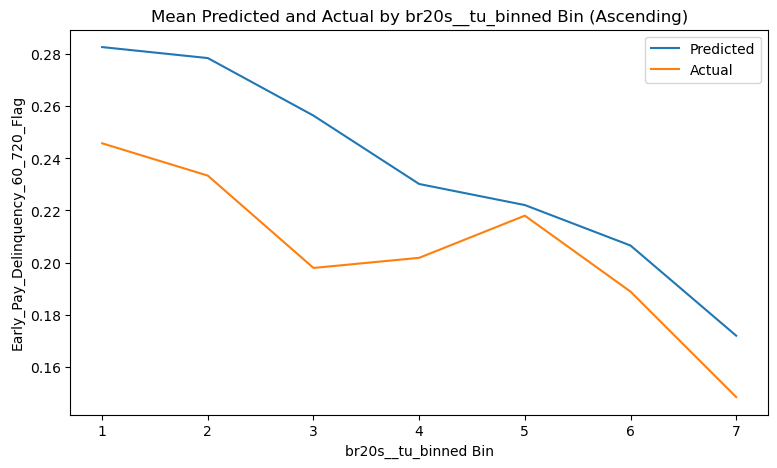

 15%|█▍        | 14/94 [00:02<00:13,  5.89it/s]

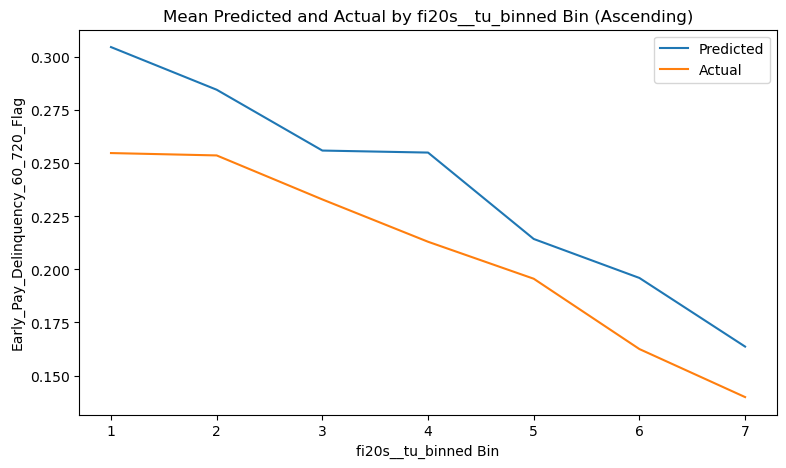

 16%|█▌        | 15/94 [00:02<00:12,  6.08it/s]

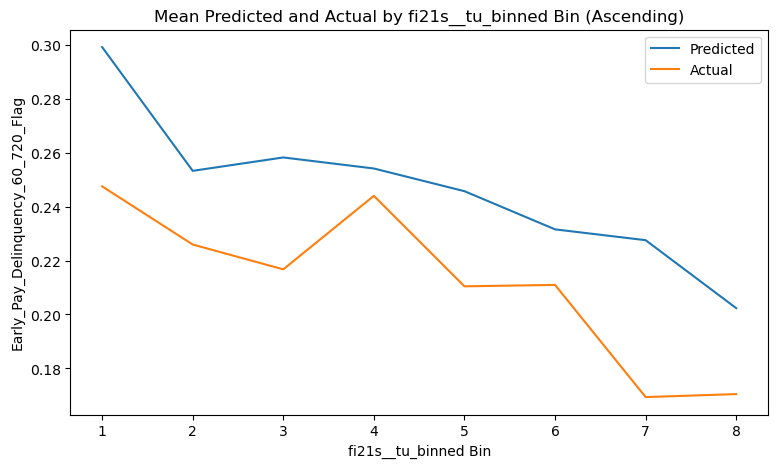

 17%|█▋        | 16/94 [00:02<00:12,  6.19it/s]

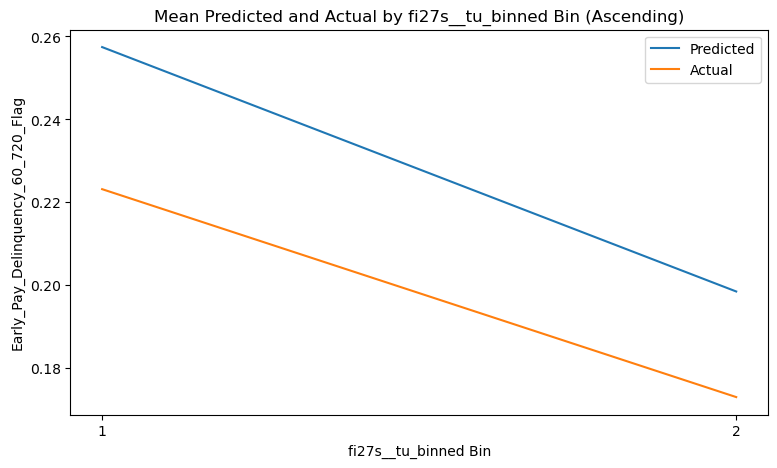

 18%|█▊        | 17/94 [00:02<00:11,  6.60it/s]

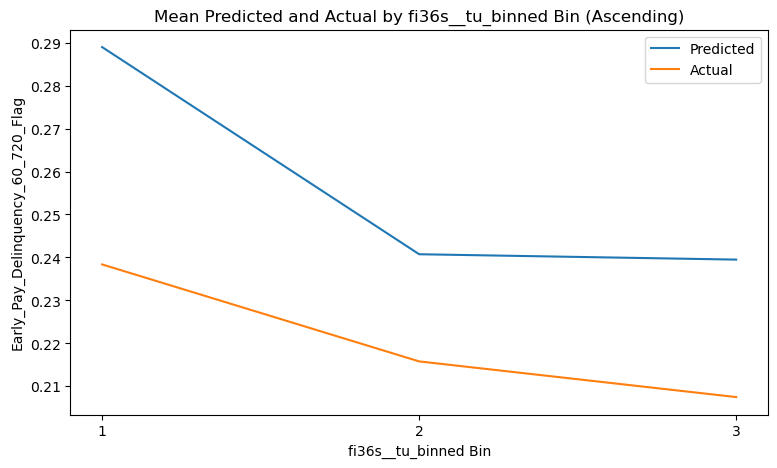

 19%|█▉        | 18/94 [00:02<00:11,  6.68it/s]

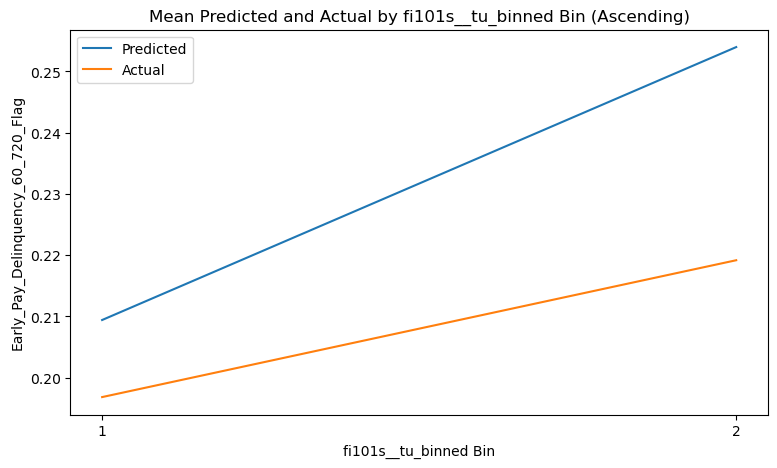

 20%|██        | 19/94 [00:02<00:10,  6.91it/s]

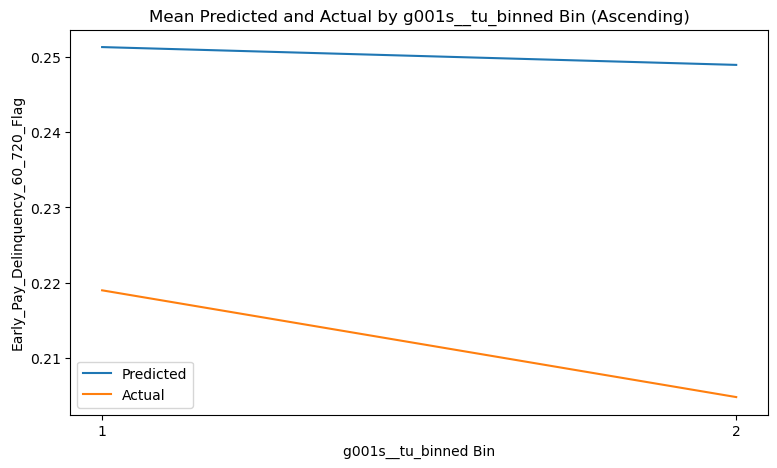

 21%|██▏       | 20/94 [00:03<00:10,  7.17it/s]

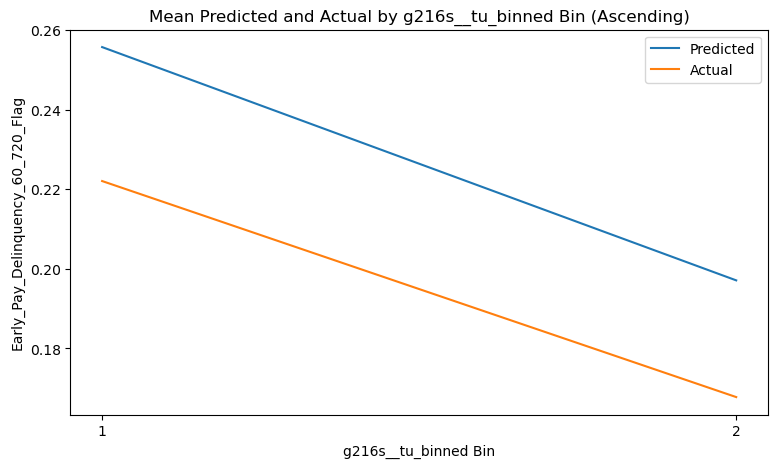

 22%|██▏       | 21/94 [00:03<00:09,  7.34it/s]

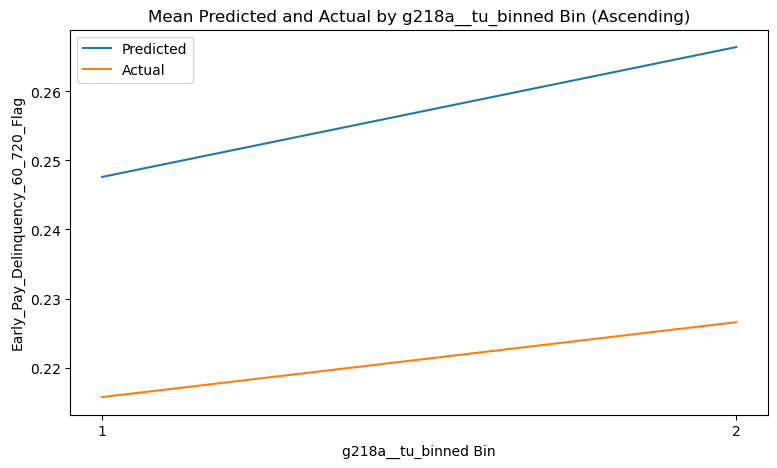

 23%|██▎       | 22/94 [00:03<00:09,  7.51it/s]

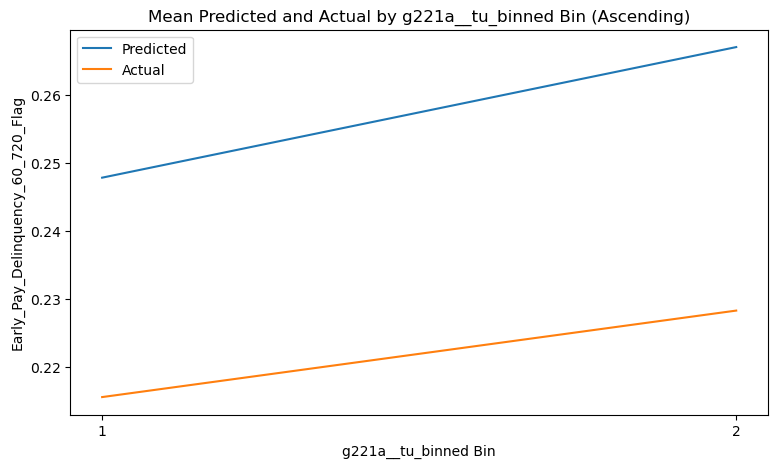

 24%|██▍       | 23/94 [00:03<00:09,  7.60it/s]

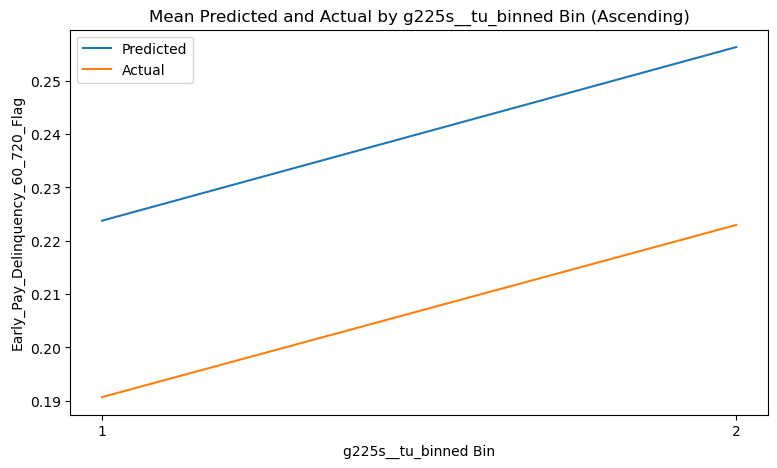

 26%|██▌       | 24/94 [00:03<00:09,  7.53it/s]

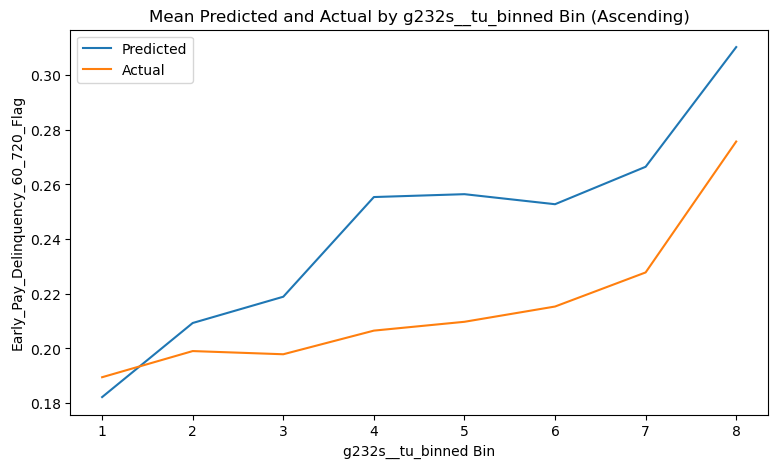

 27%|██▋       | 25/94 [00:03<00:09,  7.12it/s]

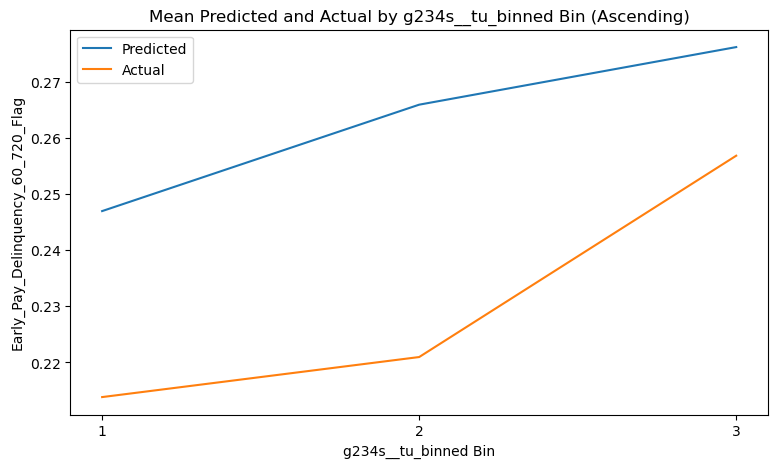

 28%|██▊       | 26/94 [00:03<00:09,  7.20it/s]

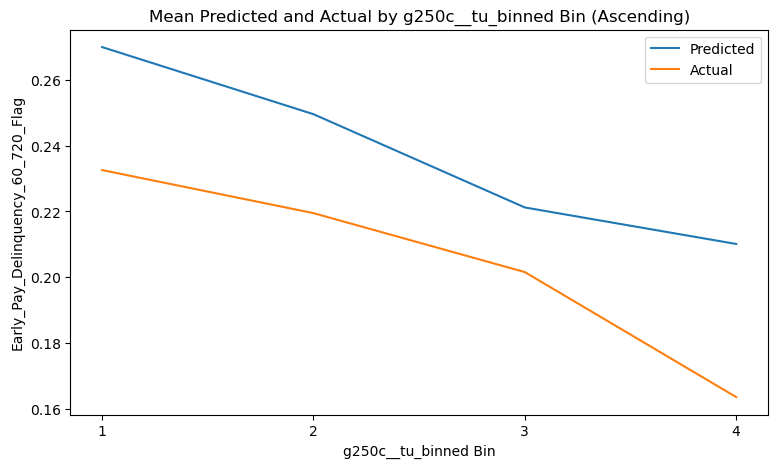

 29%|██▊       | 27/94 [00:03<00:09,  7.18it/s]

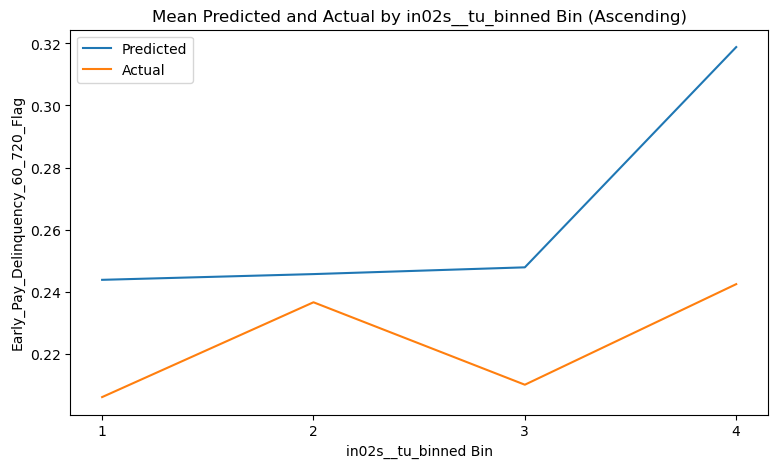

 30%|██▉       | 28/94 [00:04<00:09,  7.18it/s]

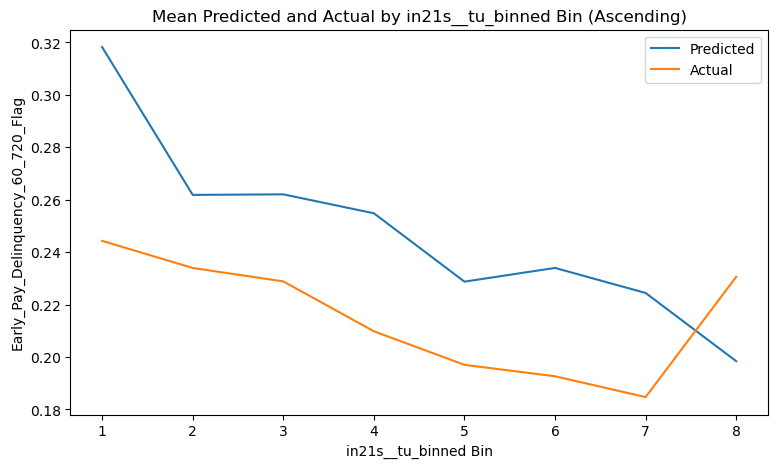

 31%|███       | 29/94 [00:04<00:09,  6.85it/s]

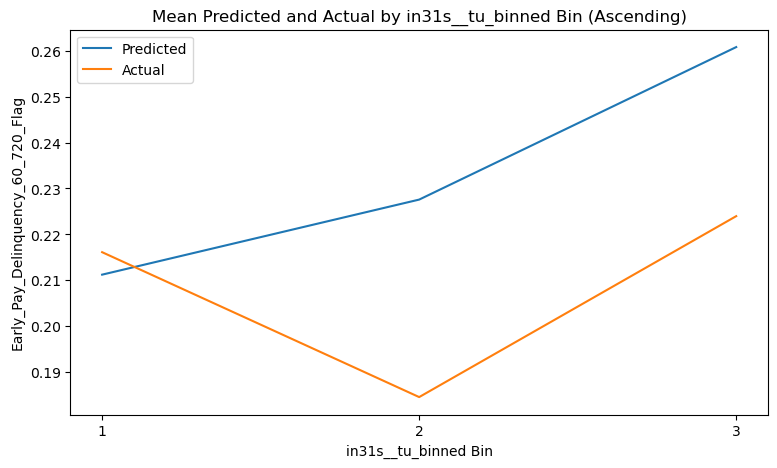

 32%|███▏      | 30/94 [00:04<00:09,  6.89it/s]

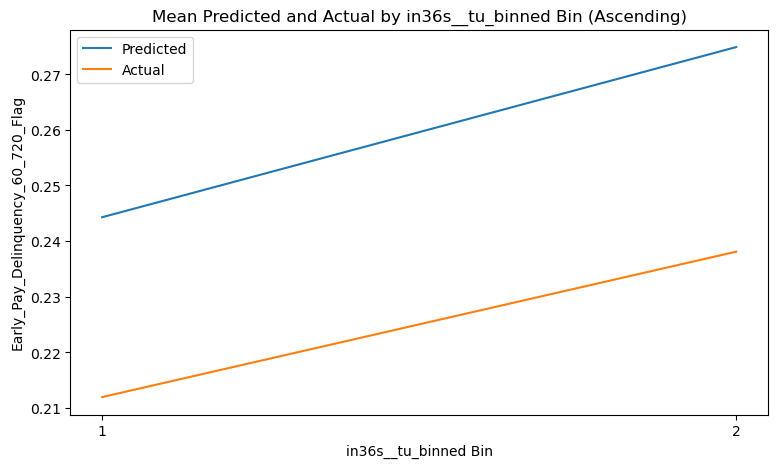

 33%|███▎      | 31/94 [00:04<00:08,  7.00it/s]

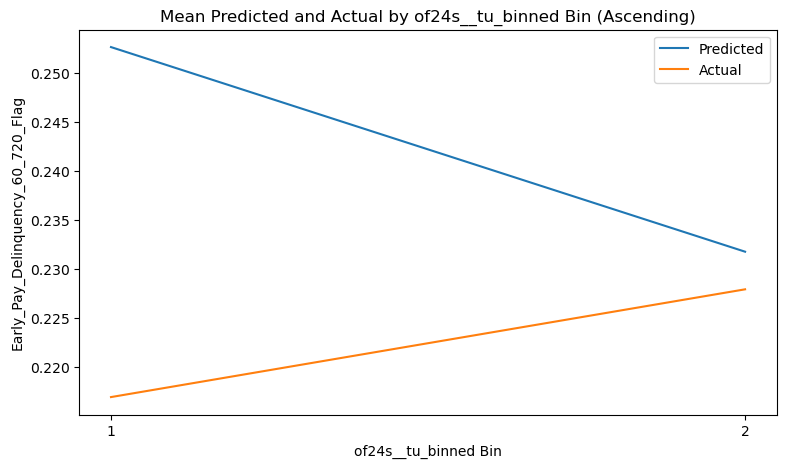

 34%|███▍      | 32/94 [00:04<00:08,  7.13it/s]

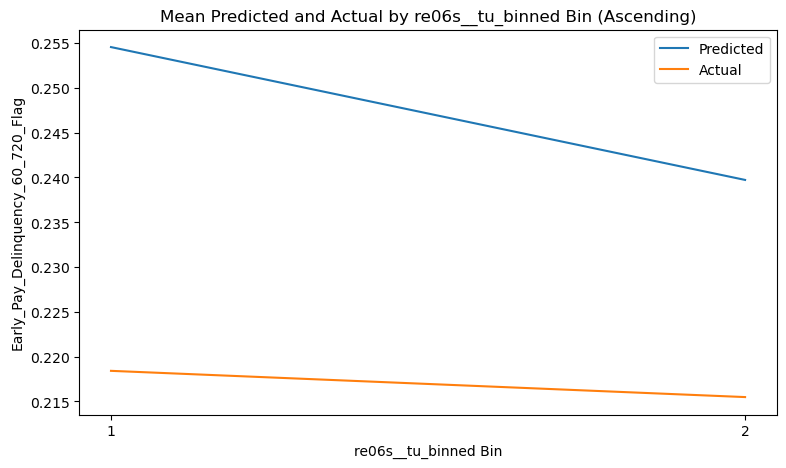

 35%|███▌      | 33/94 [00:04<00:08,  7.08it/s]

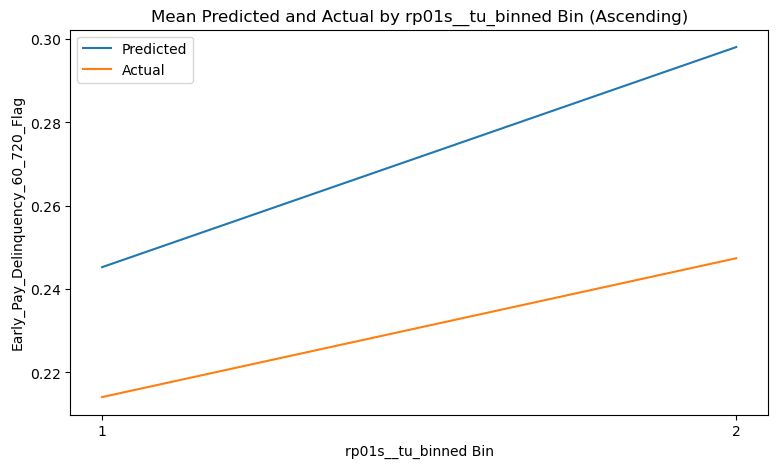

 36%|███▌      | 34/94 [00:04<00:08,  7.32it/s]

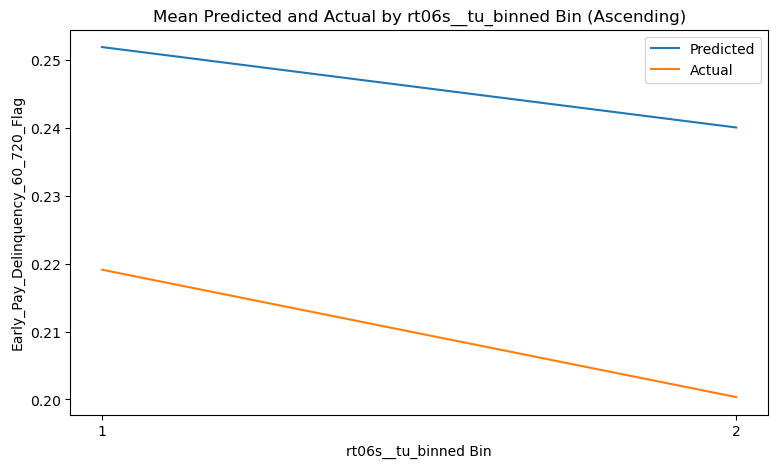

 37%|███▋      | 35/94 [00:05<00:08,  7.36it/s]

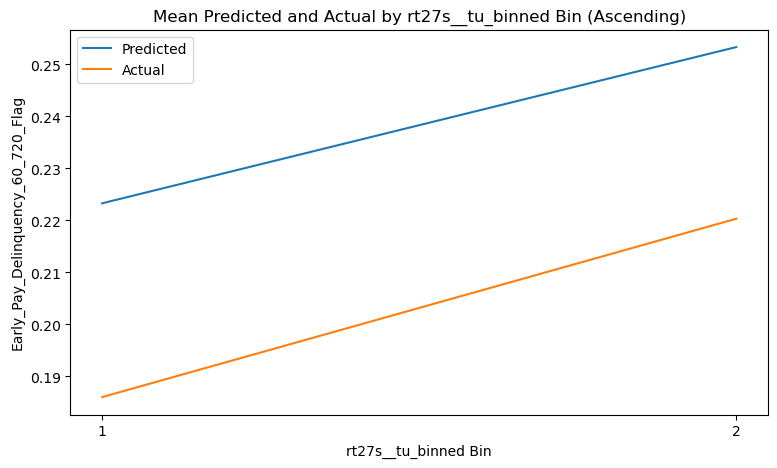

 38%|███▊      | 36/94 [00:05<00:07,  7.38it/s]

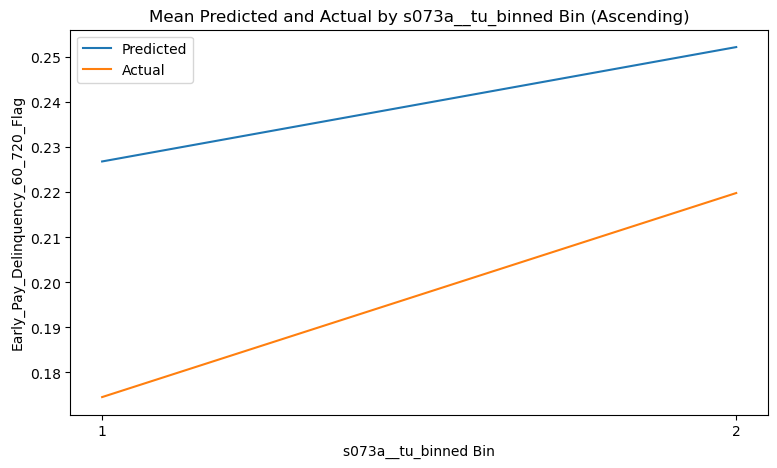

 39%|███▉      | 37/94 [00:05<00:07,  7.28it/s]

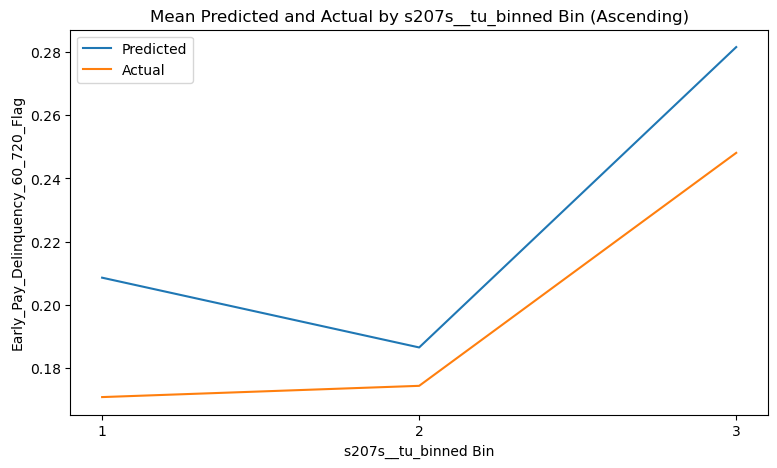

 40%|████      | 38/94 [00:05<00:07,  7.32it/s]

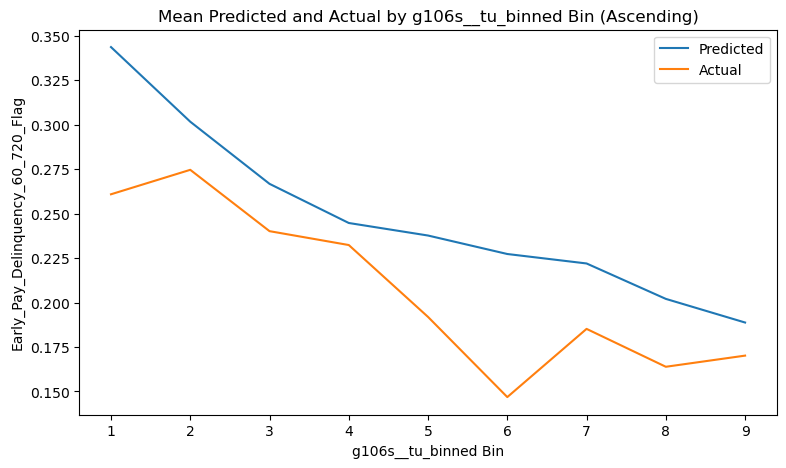

 41%|████▏     | 39/94 [00:05<00:08,  6.83it/s]

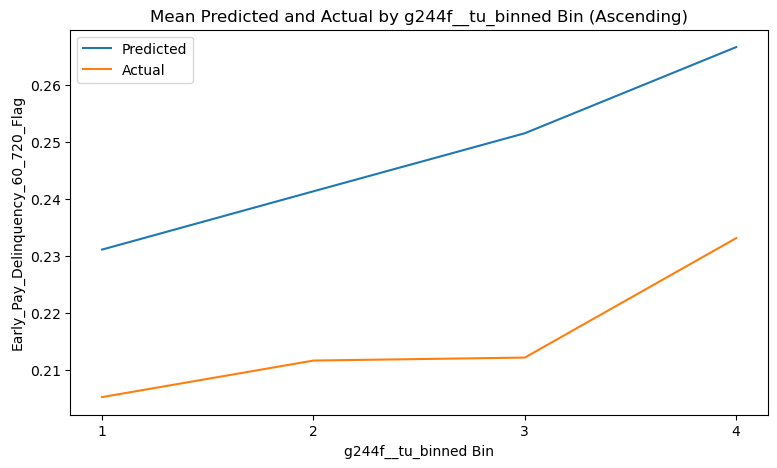

 43%|████▎     | 40/94 [00:05<00:07,  6.97it/s]

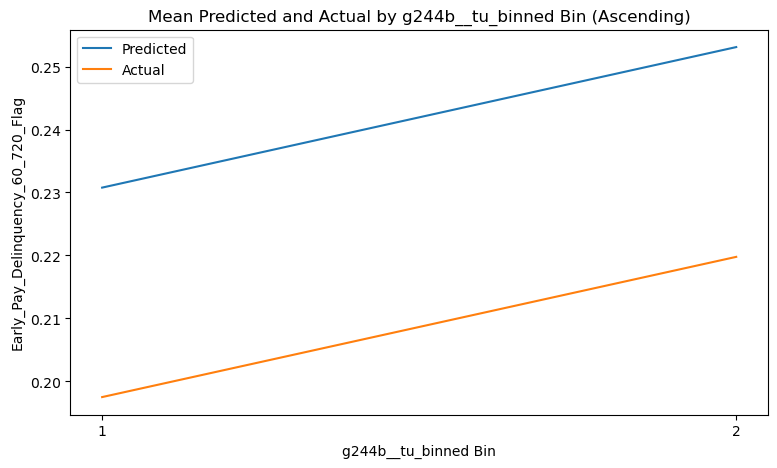

 44%|████▎     | 41/94 [00:05<00:07,  7.13it/s]

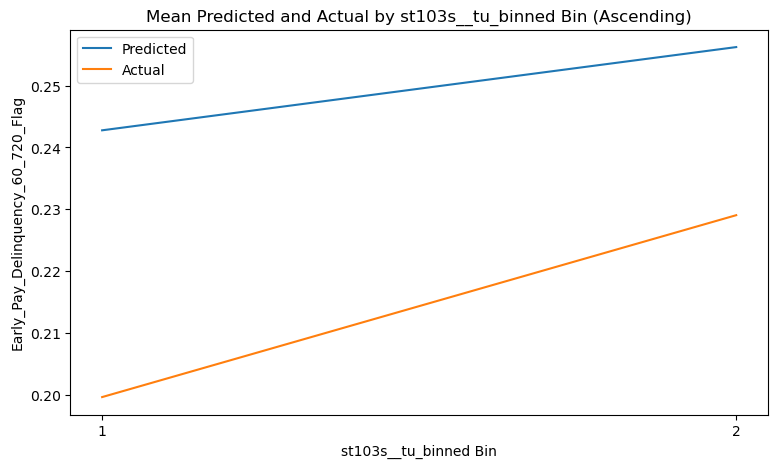

 45%|████▍     | 42/94 [00:06<00:07,  7.26it/s]

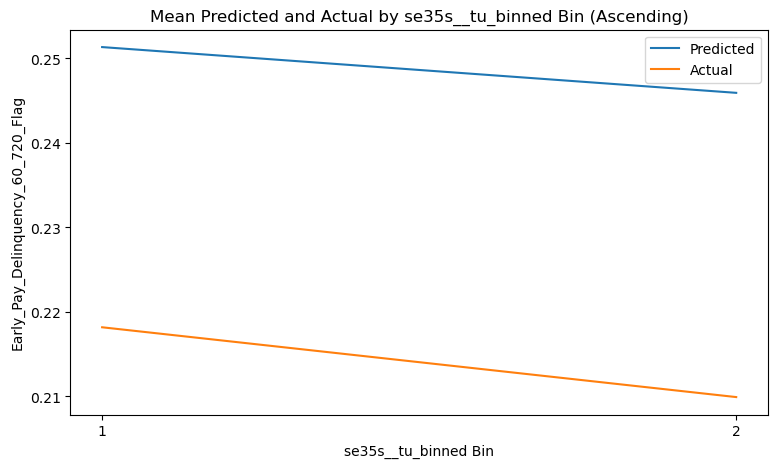

 46%|████▌     | 43/94 [00:06<00:06,  7.44it/s]

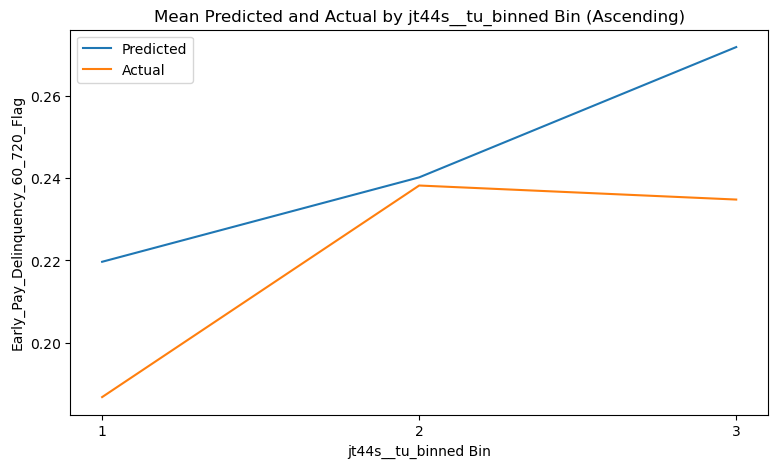

 47%|████▋     | 44/94 [00:06<00:06,  7.61it/s]

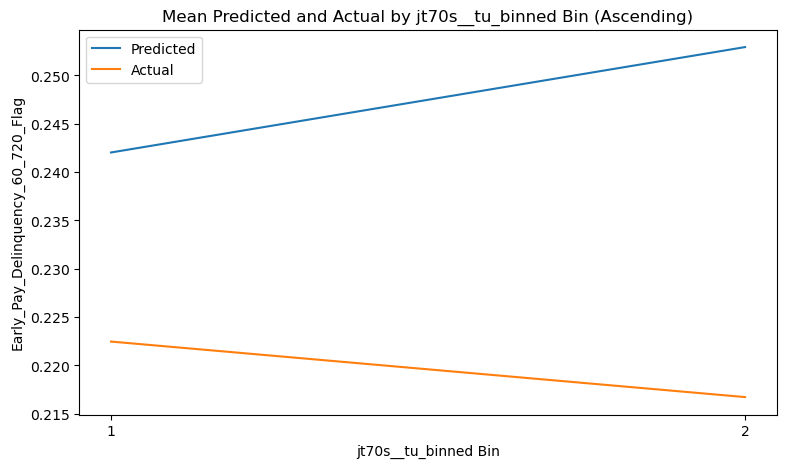

 48%|████▊     | 45/94 [00:06<00:06,  7.51it/s]

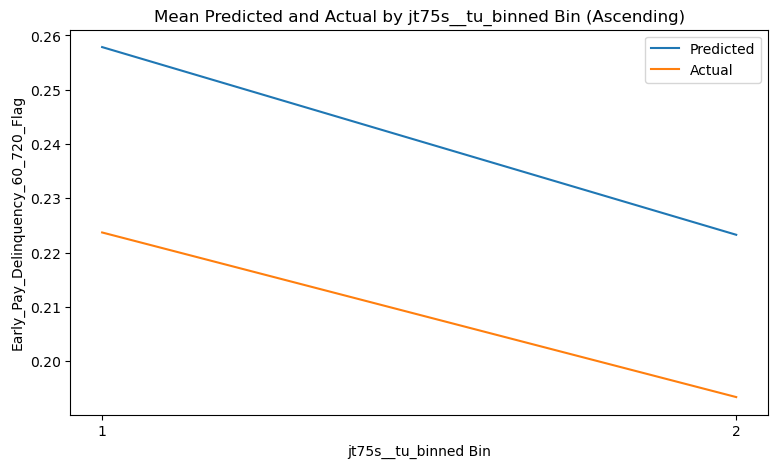

 49%|████▉     | 46/94 [00:06<00:06,  7.45it/s]

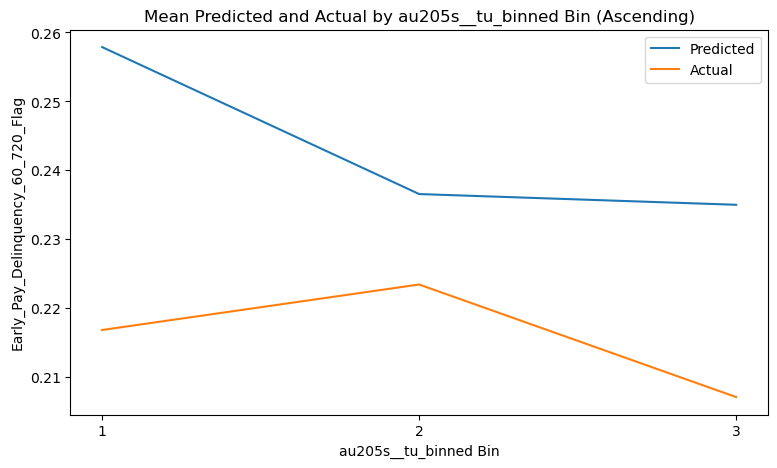

 50%|█████     | 47/94 [00:06<00:06,  7.48it/s]

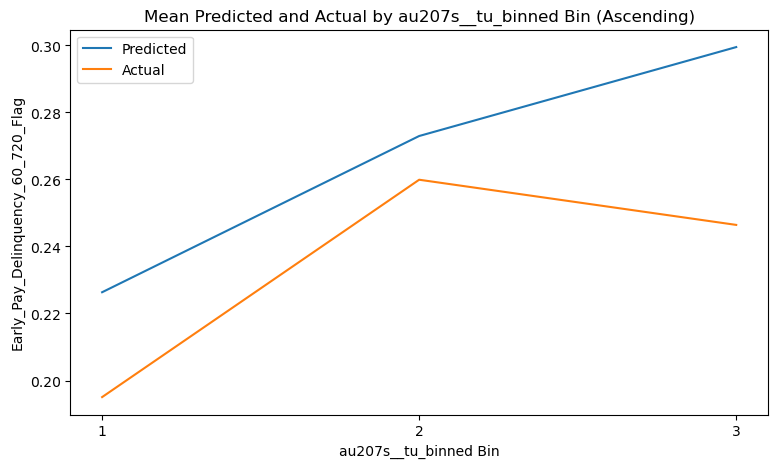

 51%|█████     | 48/94 [00:06<00:06,  7.48it/s]

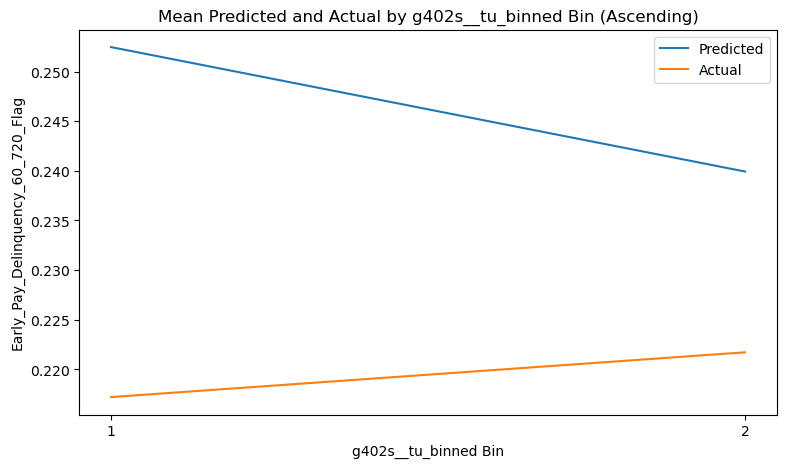

 52%|█████▏    | 49/94 [00:07<00:06,  7.49it/s]

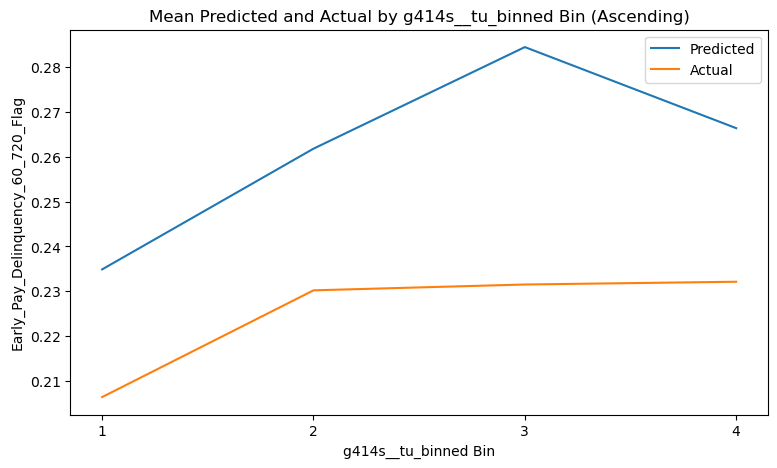

 53%|█████▎    | 50/94 [00:07<00:06,  7.30it/s]

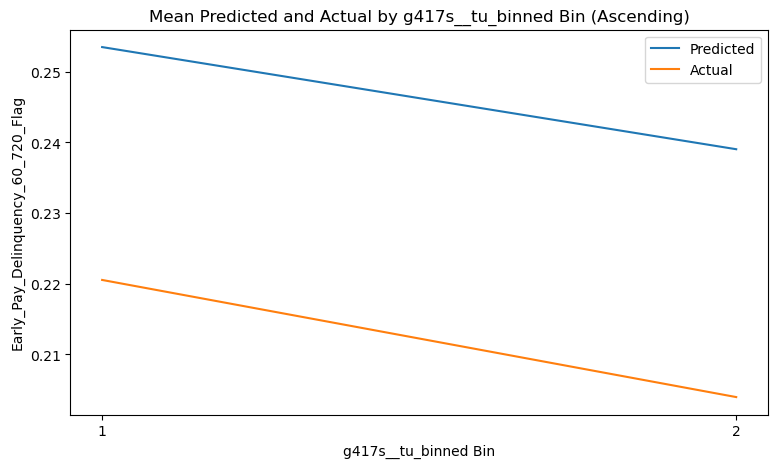

 54%|█████▍    | 51/94 [00:07<00:05,  7.53it/s]

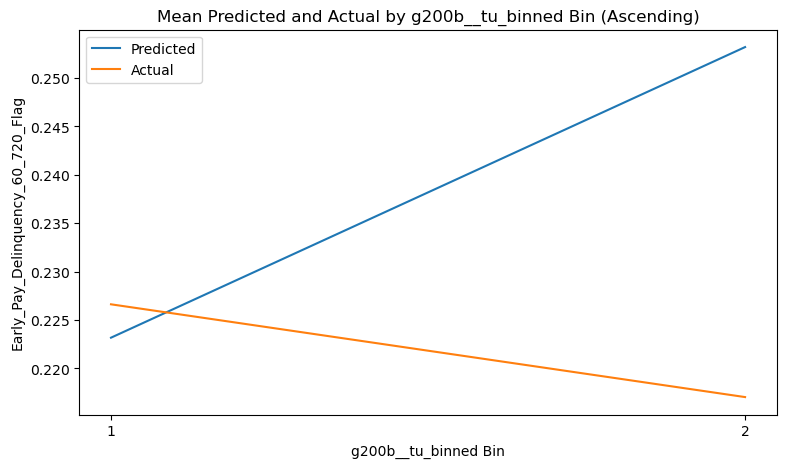

 55%|█████▌    | 52/94 [00:07<00:05,  7.50it/s]

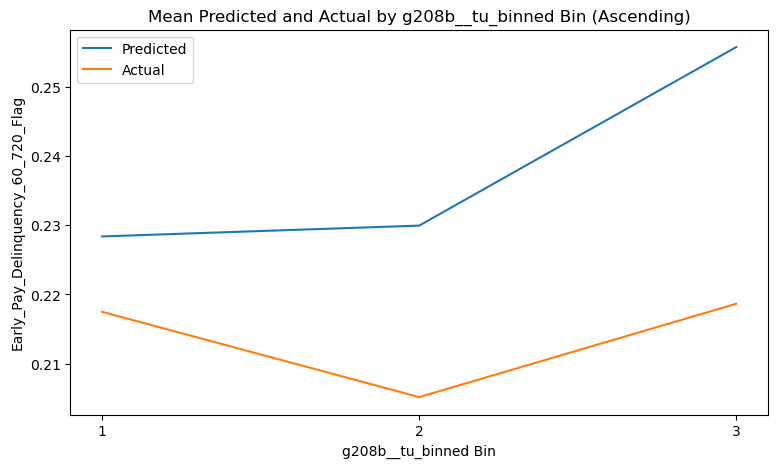

 56%|█████▋    | 53/94 [00:07<00:05,  7.60it/s]

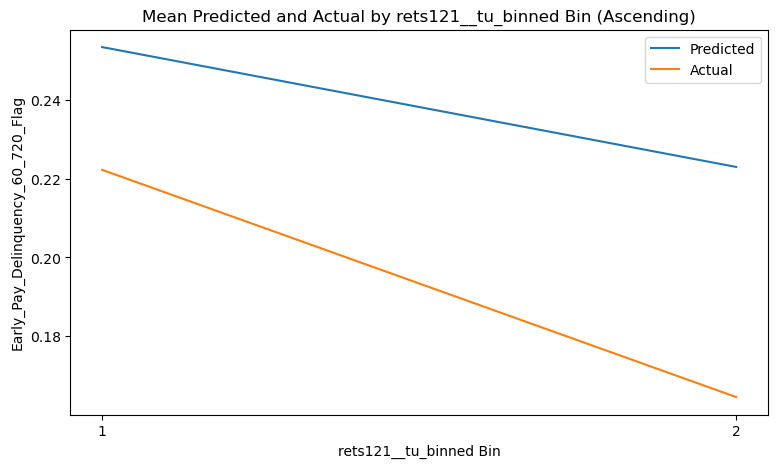

 57%|█████▋    | 54/94 [00:07<00:05,  7.80it/s]

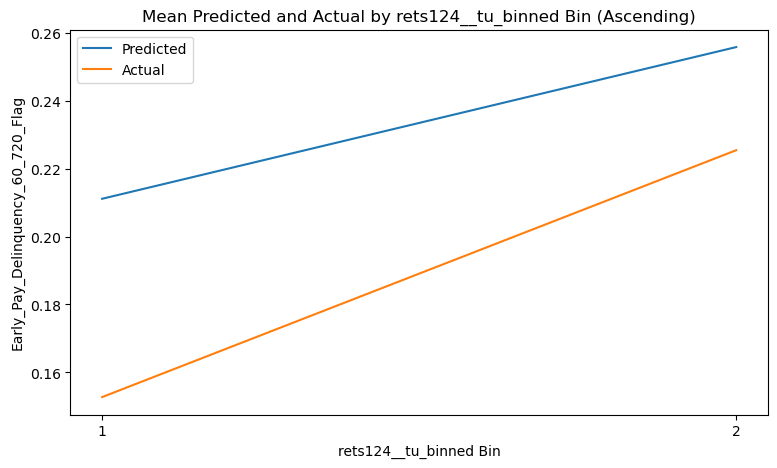

 59%|█████▊    | 55/94 [00:07<00:05,  7.79it/s]

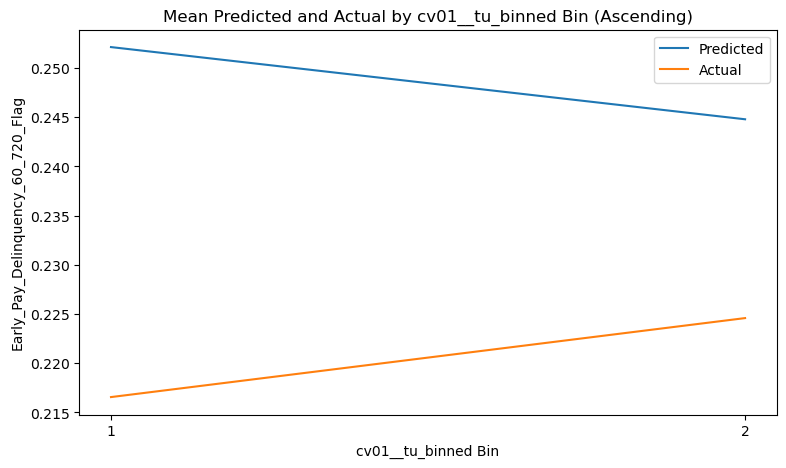

 60%|█████▉    | 56/94 [00:07<00:04,  7.64it/s]

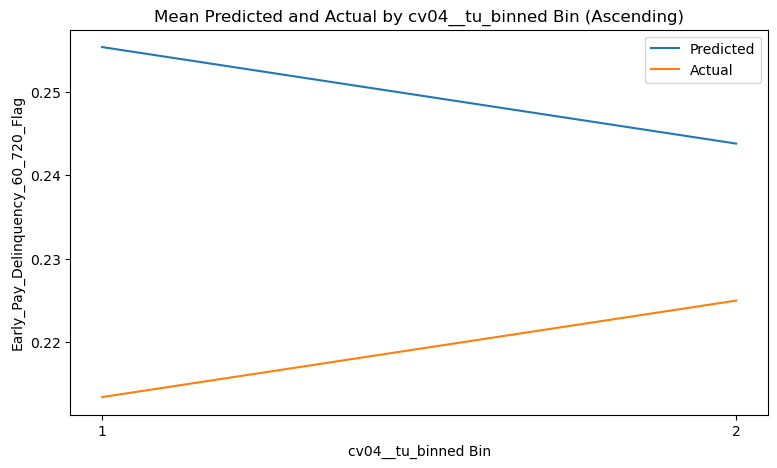

 61%|██████    | 57/94 [00:08<00:04,  7.86it/s]

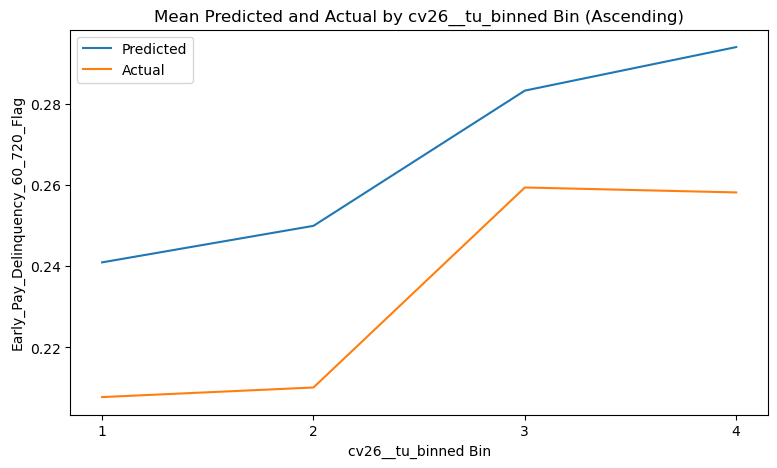

 62%|██████▏   | 58/94 [00:08<00:07,  4.98it/s]

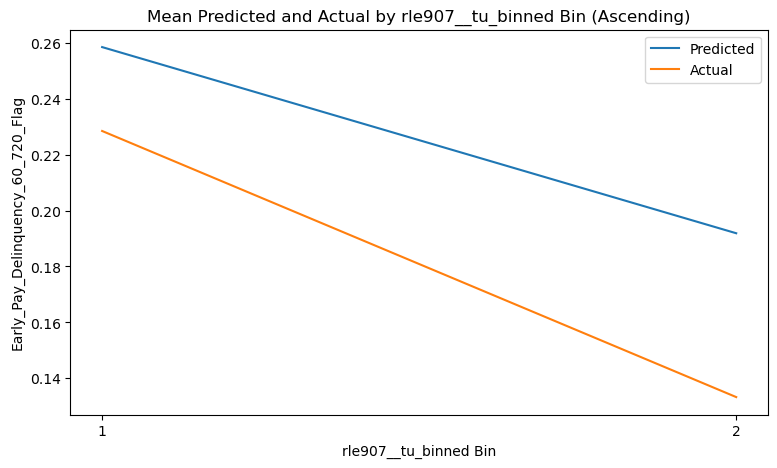

 63%|██████▎   | 59/94 [00:08<00:06,  5.55it/s]

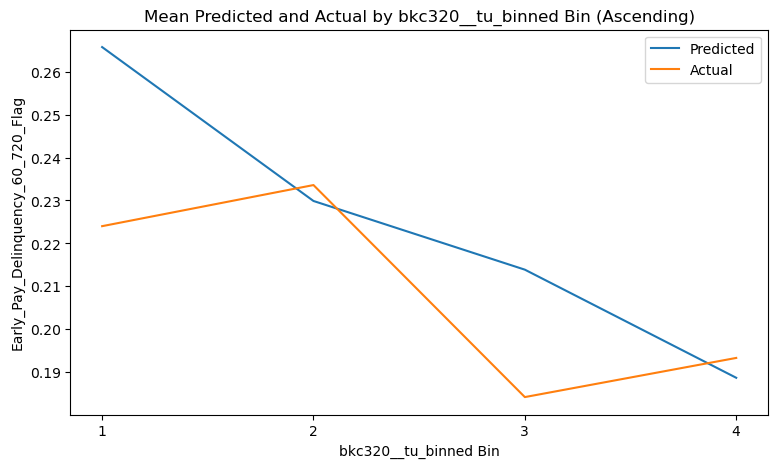

 64%|██████▍   | 60/94 [00:08<00:05,  5.89it/s]

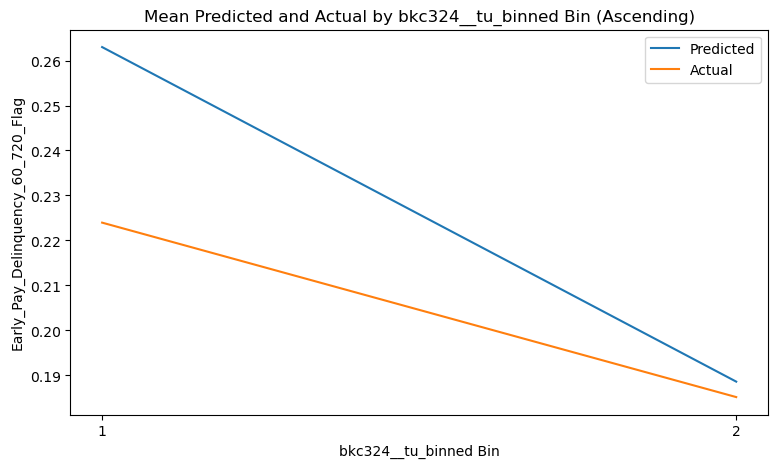

 65%|██████▍   | 61/94 [00:08<00:05,  6.23it/s]

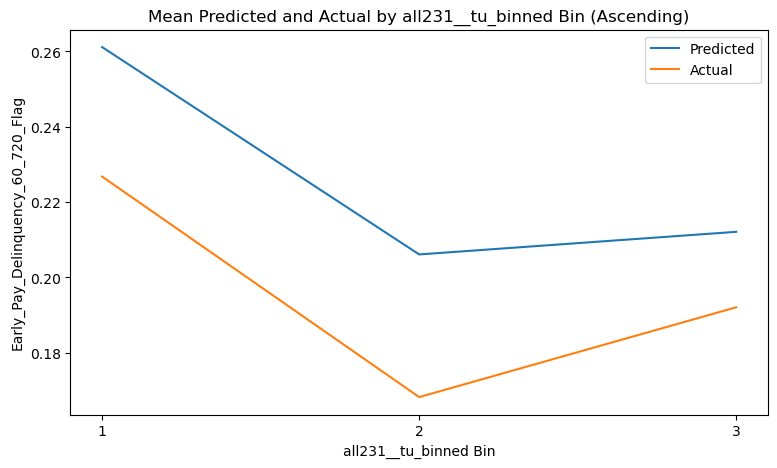

 66%|██████▌   | 62/94 [00:08<00:04,  6.62it/s]

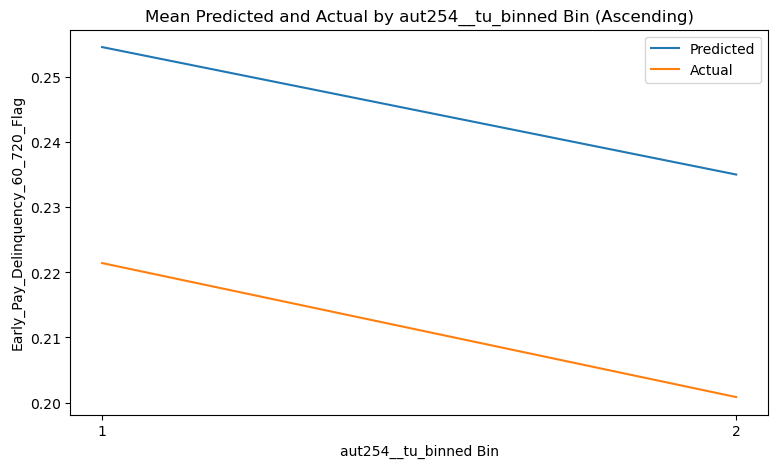

 67%|██████▋   | 63/94 [00:09<00:04,  6.90it/s]

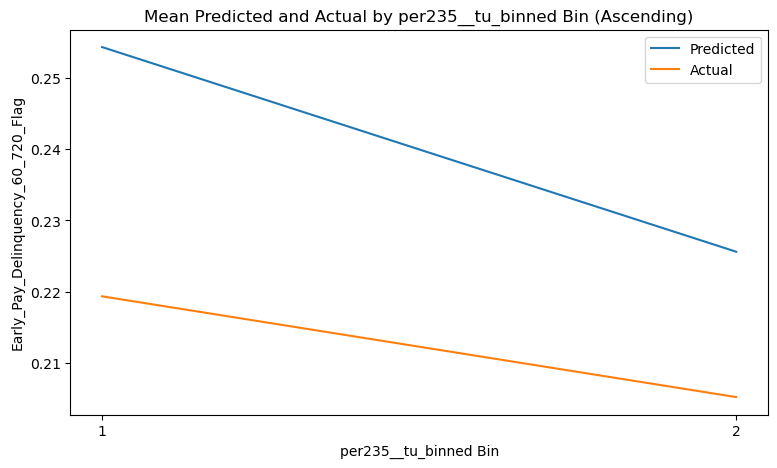

 68%|██████▊   | 64/94 [00:09<00:04,  7.18it/s]

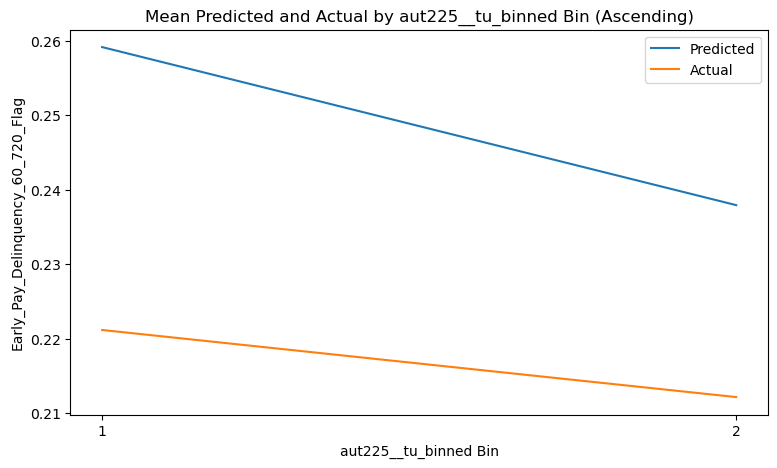

 69%|██████▉   | 65/94 [00:09<00:03,  7.35it/s]

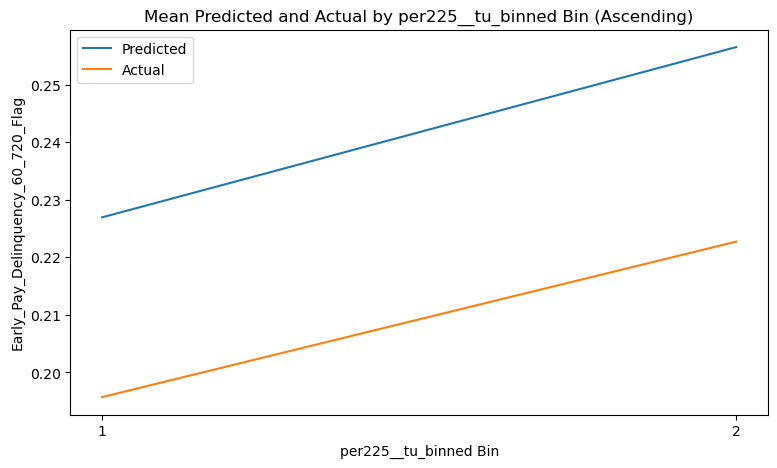

 70%|███████   | 66/94 [00:09<00:03,  7.42it/s]

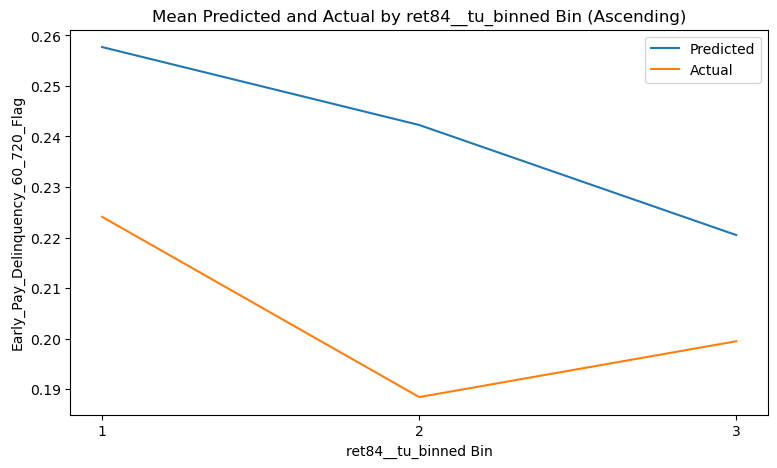

 71%|███████▏  | 67/94 [00:09<00:03,  7.32it/s]

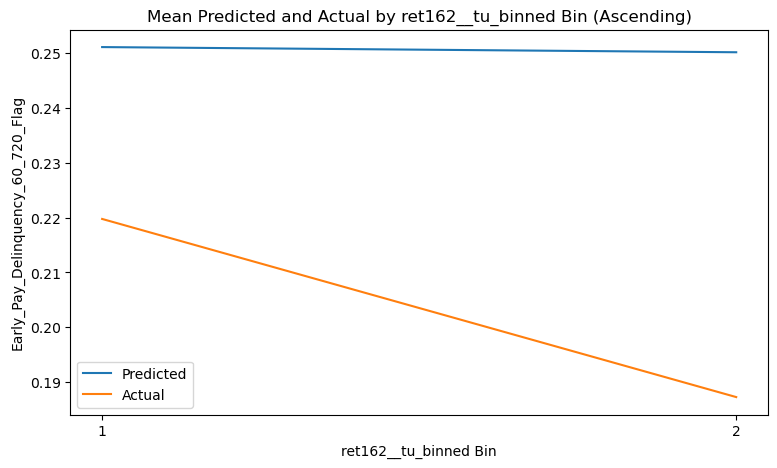

 72%|███████▏  | 68/94 [00:09<00:03,  7.34it/s]

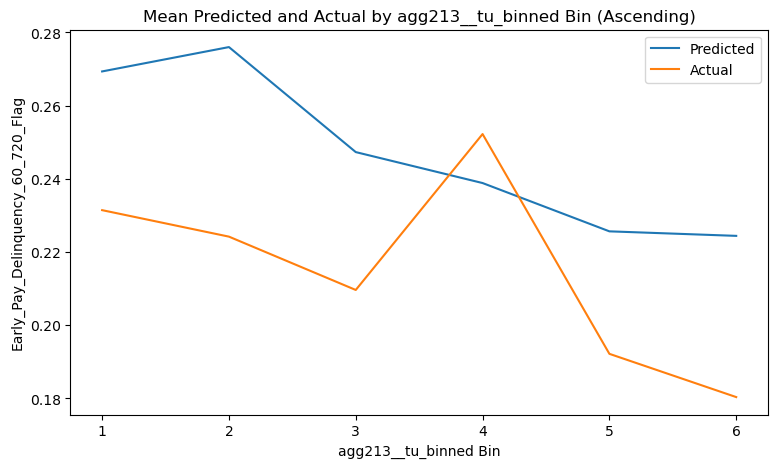

 73%|███████▎  | 69/94 [00:09<00:03,  7.21it/s]

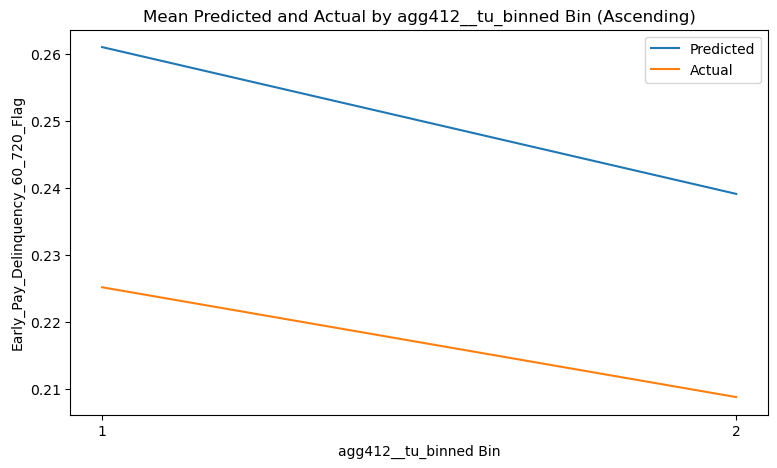

 74%|███████▍  | 70/94 [00:10<00:03,  7.33it/s]

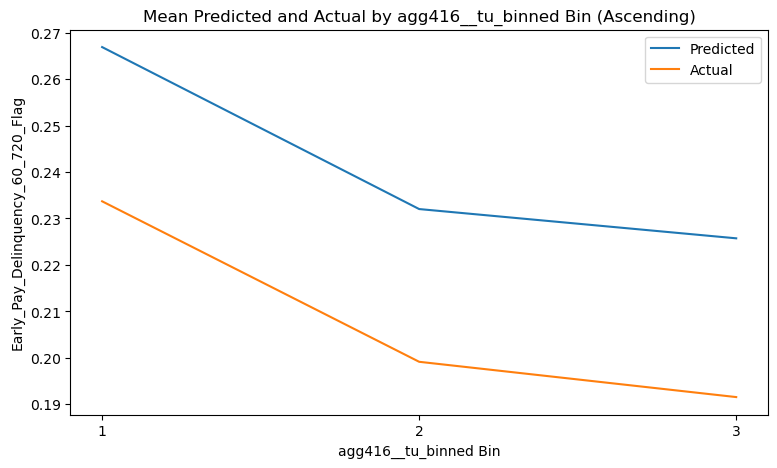

 76%|███████▌  | 71/94 [00:10<00:03,  7.17it/s]

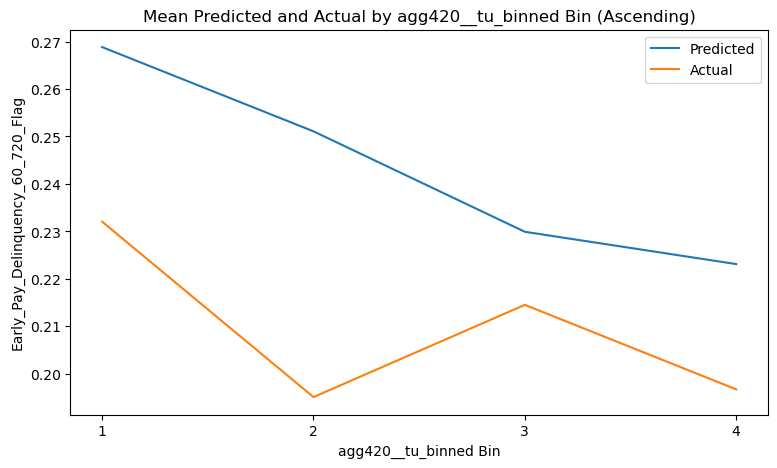

 77%|███████▋  | 72/94 [00:10<00:03,  7.06it/s]

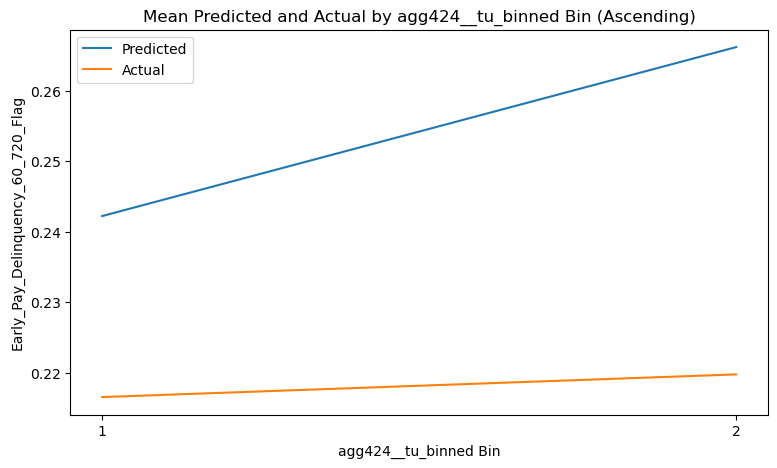

 78%|███████▊  | 73/94 [00:10<00:02,  7.33it/s]

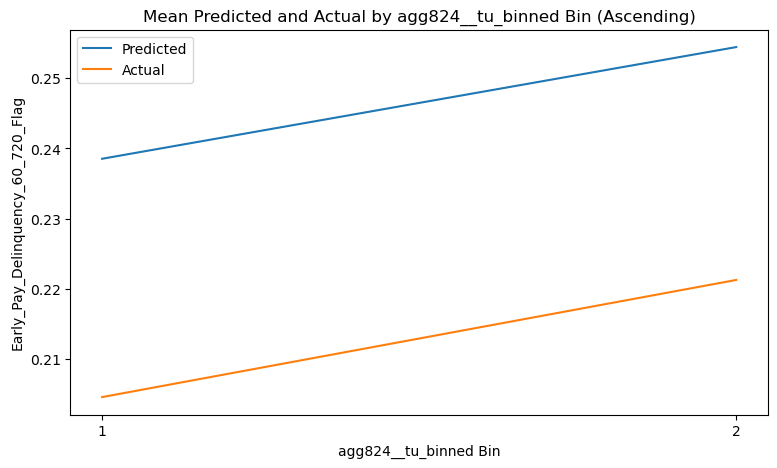

 79%|███████▊  | 74/94 [00:10<00:02,  7.49it/s]

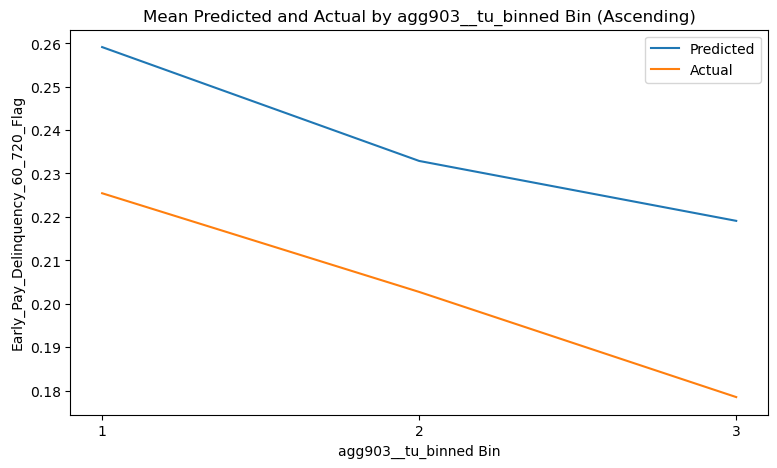

 80%|███████▉  | 75/94 [00:10<00:02,  7.29it/s]

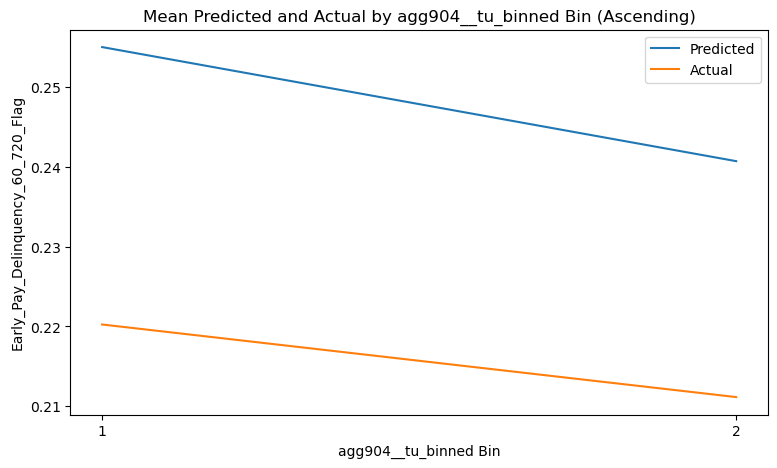

 81%|████████  | 76/94 [00:10<00:02,  7.47it/s]

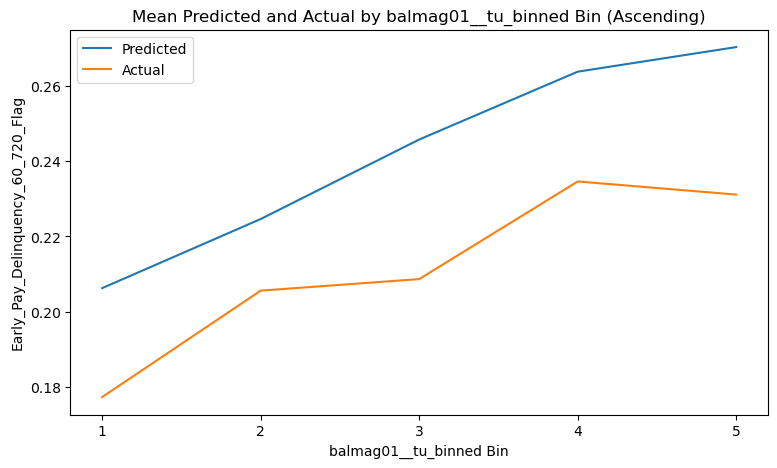

 82%|████████▏ | 77/94 [00:10<00:02,  7.41it/s]

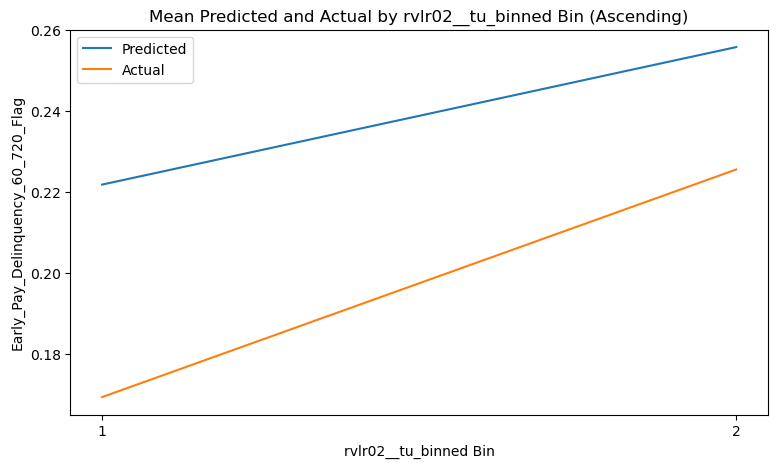

 83%|████████▎ | 78/94 [00:11<00:02,  7.52it/s]

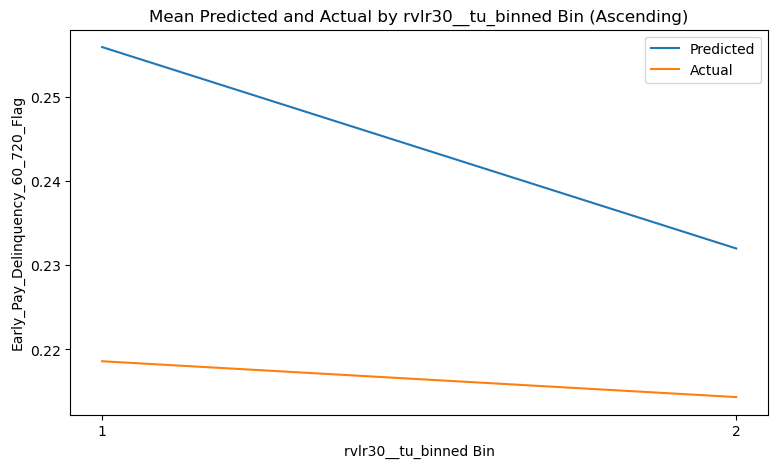

 84%|████████▍ | 79/94 [00:11<00:01,  7.71it/s]

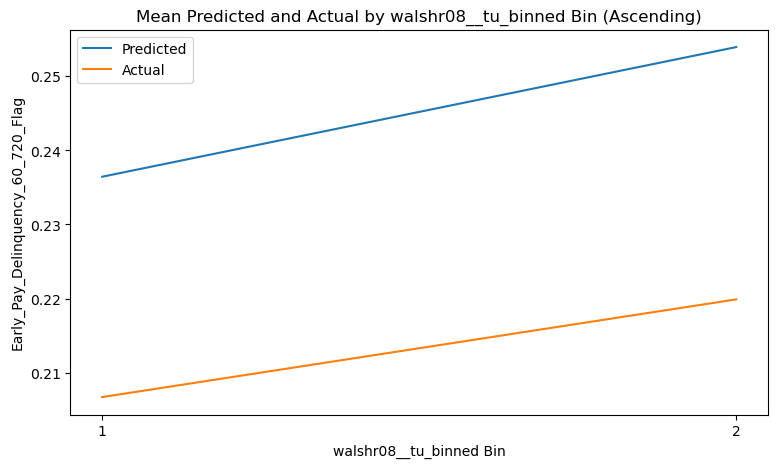

 85%|████████▌ | 80/94 [00:11<00:01,  7.73it/s]

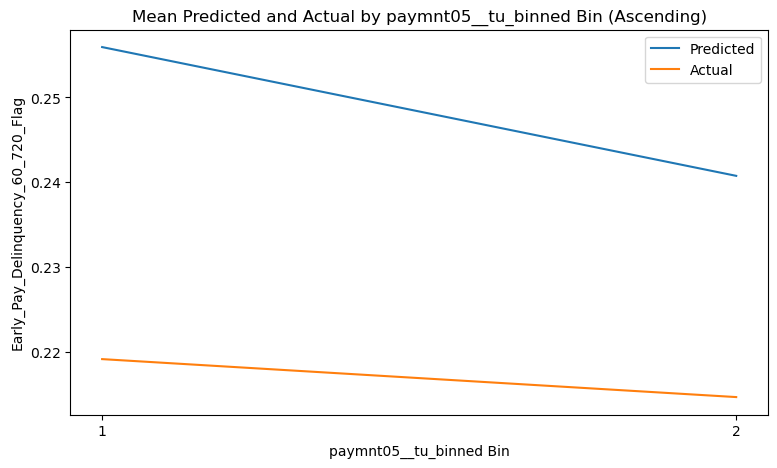

 86%|████████▌ | 81/94 [00:11<00:01,  7.86it/s]

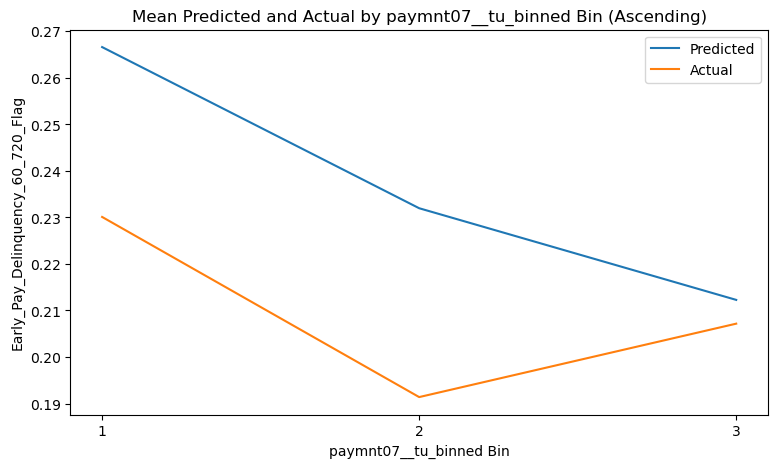

 87%|████████▋ | 82/94 [00:11<00:01,  7.44it/s]

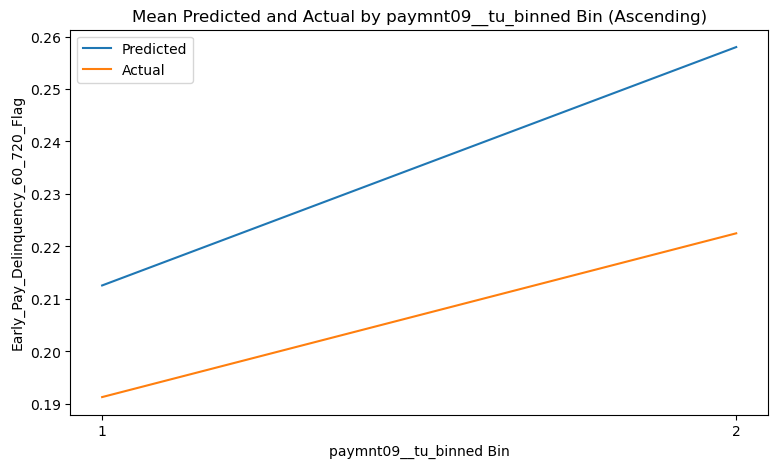

 88%|████████▊ | 83/94 [00:11<00:01,  7.31it/s]

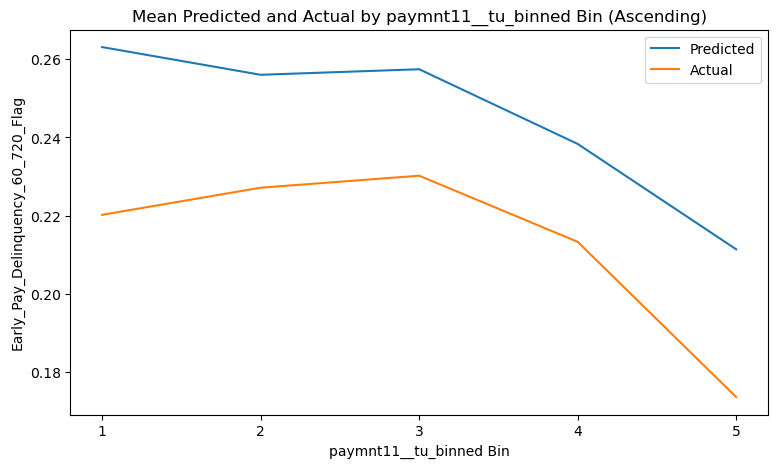

 89%|████████▉ | 84/94 [00:11<00:01,  7.22it/s]

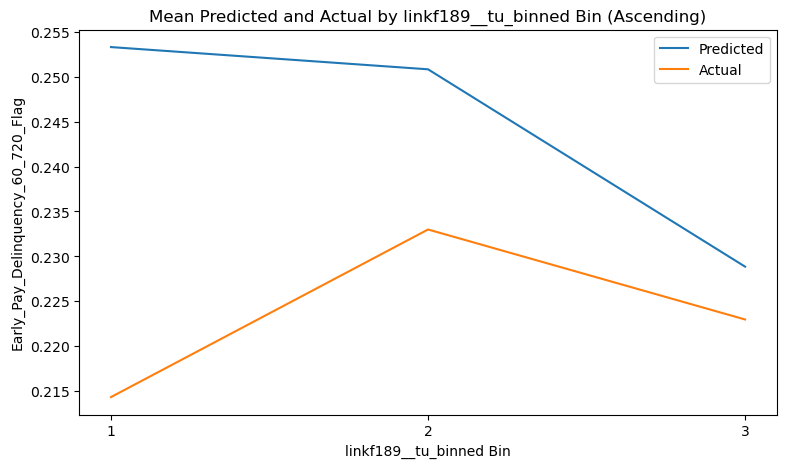

 90%|█████████ | 85/94 [00:12<00:01,  7.03it/s]

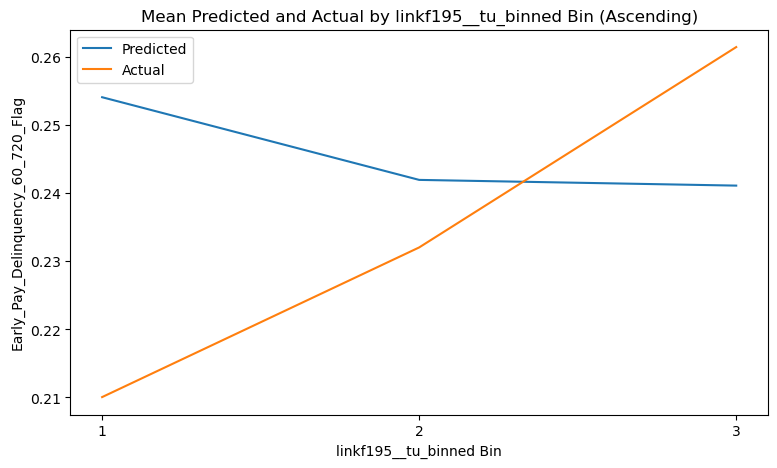

 91%|█████████▏| 86/94 [00:12<00:01,  7.07it/s]

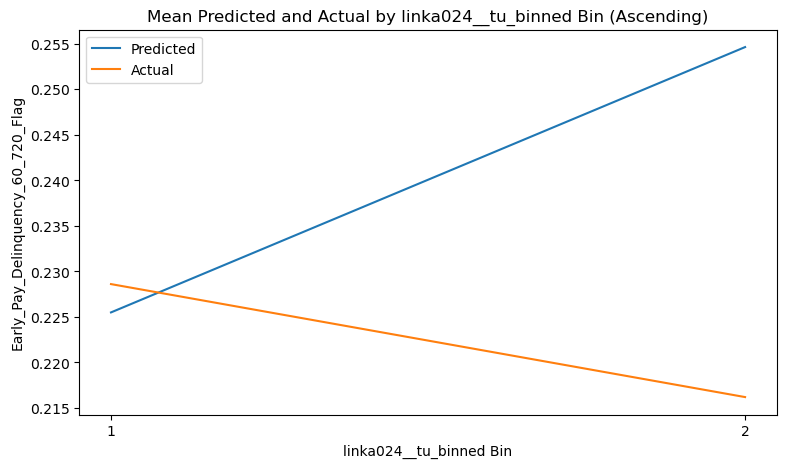

 93%|█████████▎| 87/94 [00:12<00:00,  7.00it/s]

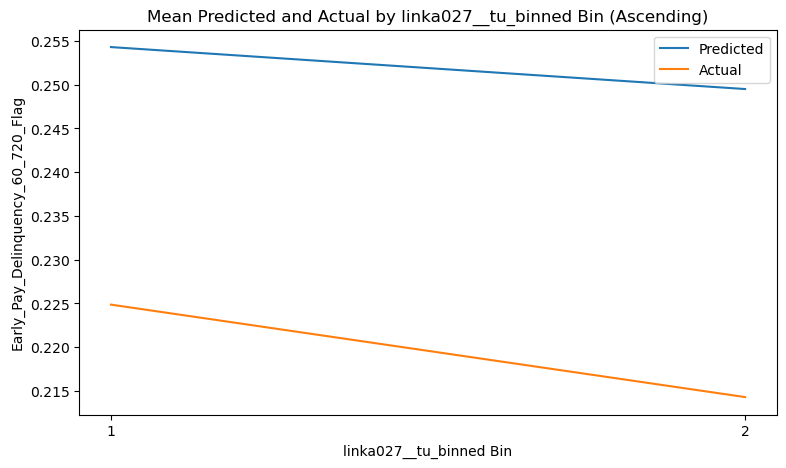

 94%|█████████▎| 88/94 [00:12<00:00,  6.94it/s]

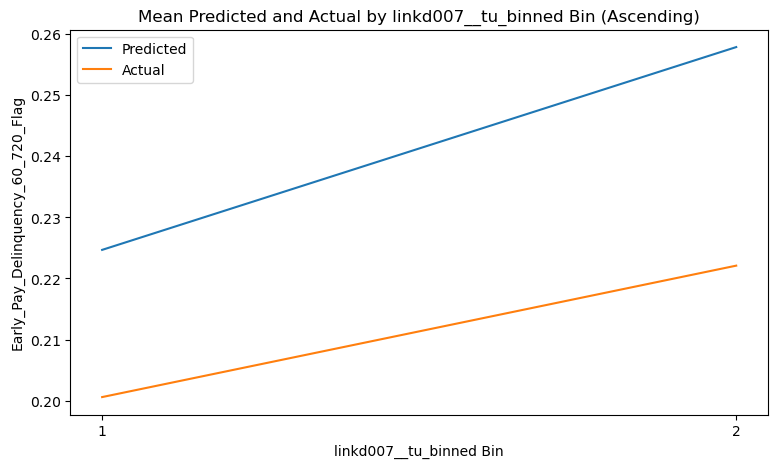

 95%|█████████▍| 89/94 [00:12<00:00,  7.04it/s]

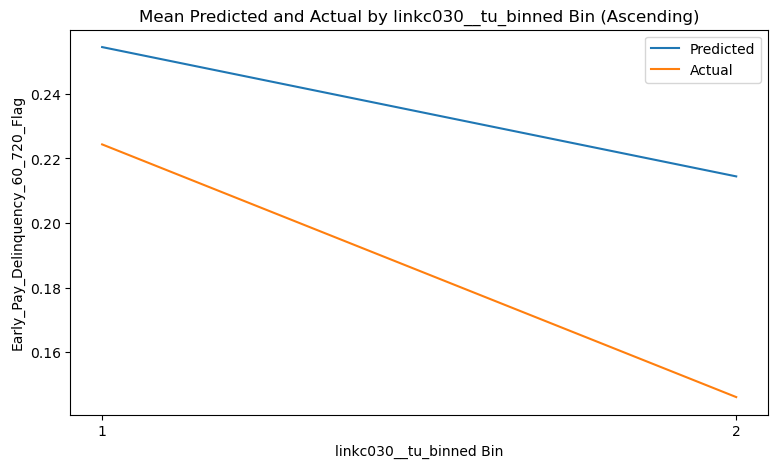

 96%|█████████▌| 90/94 [00:12<00:00,  7.22it/s]

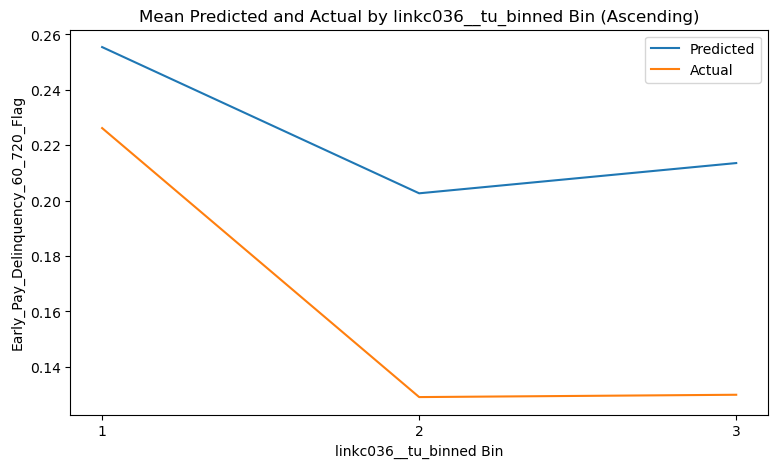

 97%|█████████▋| 91/94 [00:12<00:00,  7.20it/s]

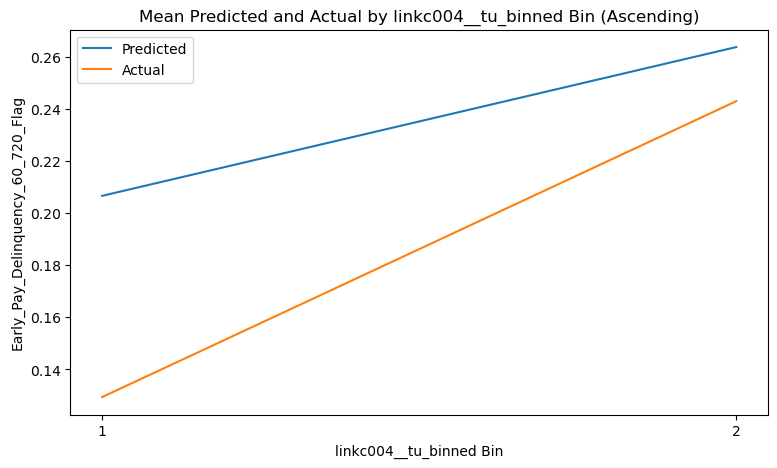

 98%|█████████▊| 92/94 [00:13<00:00,  7.20it/s]

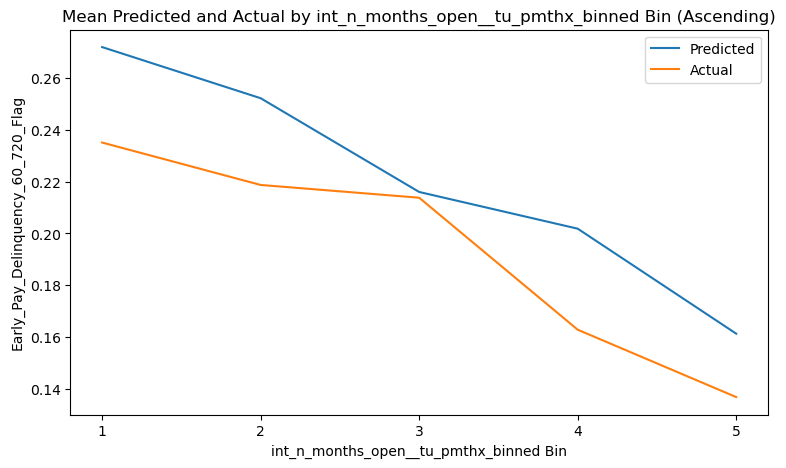

 99%|█████████▉| 93/94 [00:13<00:00,  7.03it/s]

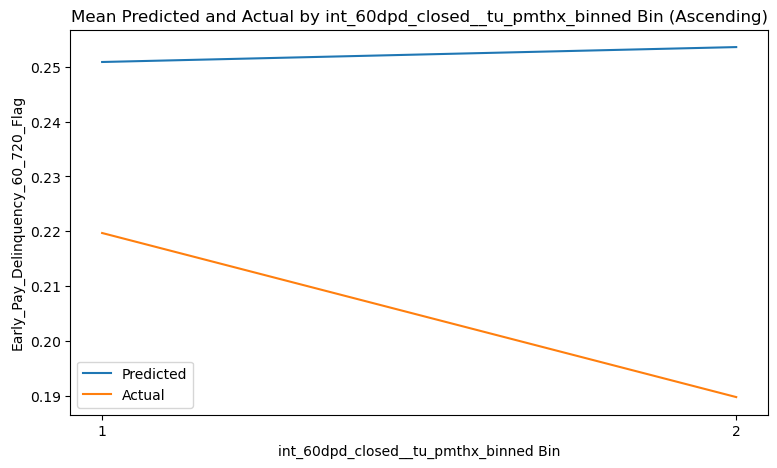

100%|██████████| 94/94 [00:13<00:00,  7.04it/s]


In [66]:
# directions of predictions
int_n_quantiles = 10
get_directions_of_predictions_for_scorecard(
    X=X_holdout.copy(),
    list_predictions=list_predictions_holdout,
    str_target=str_target,
    list_actual=list(y_holdout),
    list_cols=list_cols_scorecard,
    df_bins=df_bins,
)

#### What does the scorecard like?

In [67]:
# copy df_bins
df_identity = df_bins[df_bins['feature'].isin(list_cols_scorecard)].copy()

df_coef = pd.DataFrame({
    'feature': cls_model_inference.feature_names_in_,
    'coef': cls_model_inference.coef_[0],
})
# create dictionary
dict_map_coef = dict(zip(df_coef['feature'], df_coef['coef']))

# map to df_identity
df_identity['coef'] = df_identity['feature'].map(dict_map_coef)

# multiply by bin value
df_identity['contribution'] = df_identity['bin'] * df_identity['coef']

# sort
df_identity.sort_values(by=['feature','contribution'], ascending=[True,True], inplace=True)

# get description
df_identity['description'] = df_identity['feature'].map(dict_map_descriptions_bin)

# save
str_filename = 'df_scorecard.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_identity.to_csv(str_local_path, index=False)

# show
df_identity

,feature,bin,min,max,count,prop,target,bin_label,coef,contribution,description
5,ENG-loan_to_value_binned,0.723279,0.185468,1.006807,821,0.051197,0.154689,1,-0.877327,-0.634552,NaN
4,ENG-loan_to_value_binned,0.239584,1.006826,1.141622,2333,0.145485,0.228890,2,-0.877327,-0.210194,NaN
3,ENG-loan_to_value_binned,0.039839,1.141627,1.247020,3680,0.229484,0.266033,3,-0.877327,-0.034952,NaN
2,ENG-loan_to_value_binned,-0.043577,1.247047,1.263332,835,0.052070,0.282635,4,-0.877327,0.038231,NaN
1,ENG-loan_to_value_binned,-0.066428,1.263349,1.433861,5799,0.361624,0.287291,5,-0.877327,0.058279,NaN
...,...,...,...,...,...,...,...,...,...,...,...
0,se35s__tu_binned,-0.003307,1.000000,1616.000000,15229,0.949676,0.274542,1,-0.080199,0.000265,Average balance of open secured installment tr...
0,st103s__tu_binned,-0.005618,24.000000,28.000000,10069,0.627900,0.275002,2,0.240564,-0.001352,Number of student loans in deferment
1,st103s__tu_binned,0.009513,0.000000,23.000000,5967,0.372100,0.271996,1,0.240564,0.002288,Number of student loans in deferment
0,walshr08__tu_binned,-0.010180,52.180000,93.800000,14211,0.886194,0.275913,2,1.154281,-0.011751,Max wallet share shift in last 12 months


#### Show only the best one by feature

In [68]:
df_identity_sub = df_identity.drop_duplicates(subset=['feature'], keep='first', inplace=False)

# sort
df_identity_sub.sort_values(by='contribution', ascending=True, inplace=True)

# save
str_filename = 'df_scorecard_sub.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_identity_sub.to_csv(str_local_path, index=False)

# show
df_identity_sub

,feature,bin,min,max,count,prop,target,bin_label,coef,contribution,description
5,ENG-loan_to_value_binned,0.723279,1.854683e-01,1.006807,821,0.051197,0.154689,1,-0.877327,-0.634552,NaN
7,g232s__tu_binned,0.338278,0.000000e+00,2.000000,1156,0.072088,0.211938,1,-1.100749,-0.372360,Number of inquiries (includes duplicates)
7,in21s__tu_binned,0.403775,8.400000e+01,456.000000,830,0.051759,0.201205,8,-0.909736,-0.367329,Months since most recent installment trade opened
1,fi101s__tu_binned,0.258184,0.000000e+00,40.000000,882,0.055001,0.225624,1,-1.232620,-0.318242,Total balance of all finance installment trade...
4,dti__app_binned,0.321242,1.702548e-07,0.295007,1676,0.104515,0.214797,1,-0.973438,-0.312709,NaN
...,...,...,...,...,...,...,...,...,...,...,...
0,linkf189__tu_binned,-0.007178,0.000000e+00,716.000000,12513,0.780307,0.275314,1,0.098473,-0.000707,Age of newest inquiry STOREFRONT LENDER
0,jt70s__tu_binned,-0.001389,1.000000e+01,100.000000,13514,0.842729,0.274160,2,0.211998,-0.000295,Ratio of dollars past due joint trades to tota...
0,g244b__tu_binned,-0.002993,1.000000e+00,28.000000,14839,0.925355,0.274479,2,0.024483,-0.000073,Number of bank inquiries (includes duplicates)...
0,g001s__tu_binned,-0.004297,0.000000e+00,5.000000,15138,0.944001,0.274739,1,0.006359,-0.000027,Number of 30 days past due ratings in past 12 ...


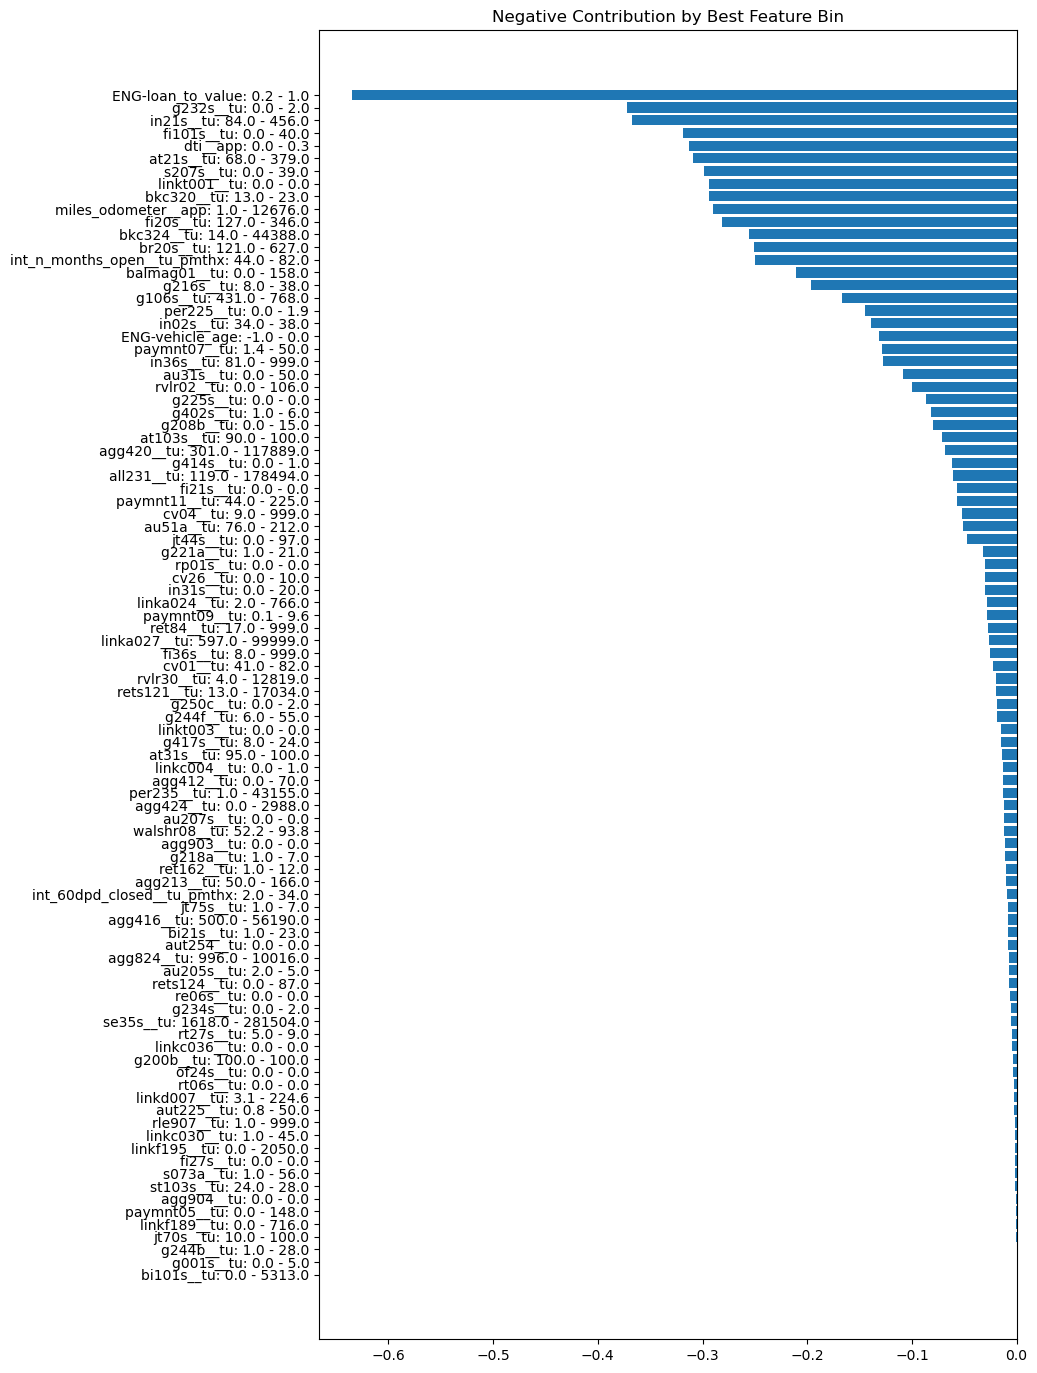

In [69]:
# plot
df_identity_sub['label'] = df_identity_sub.apply(
    lambda x: f"{x['feature'].split('_binned')[0]}: {x['min']:0.1f} - {x['max']:0.1f}",
    axis=1,
)

# plot
df_identity_sub.sort_values(by='contribution', ascending=False, inplace=True)
x = df_identity_sub['label']
y = df_identity_sub['contribution']
fig, ax = plt.subplots(figsize=(9,17))
ax.set_title('Negative Contribution by Best Feature Bin')
ax.barh(x, y)
# show
plt.show()